## 1. Izpit 23/24

#### 1. naloga: Prehrana

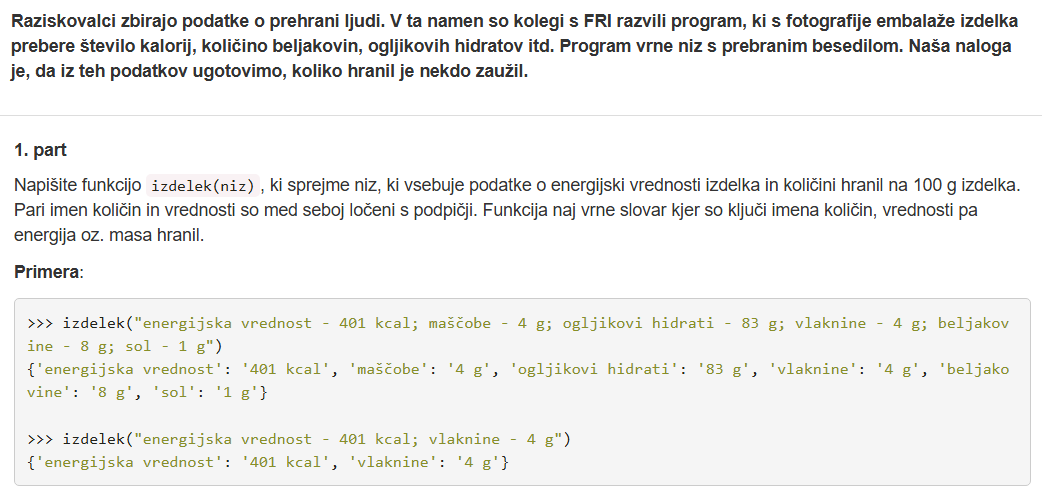

In [7]:
niz = "energijska vrednost - 401 kcal; vlaknine - 4 g"

def izdelek(niz):
    slovar = {}
    razdelitev = niz.split(";")

    for delcek in razdelitev:
        par = delcek.split("-") # zdaj je par = ["energijska vrednost ", " 401 kcal"]
        slovar[par[0].strip()] = par[1].strip() # .strip() odstrani presledke na koncu in začetku niza, to zdaj pomeni: v slovar daj
        # kljuc in mu pripiši vrednost par[1] -> slovar[ključ] = vrednost

    return slovar

print(izdelek(niz))

# uradna rešitev:

def izdelek(niz):
    slovar = {}

    kategorije = niz.split(";")

    for kategorija in kategorije:
        par = kategorija.split("-") # to je bolj pregledano kot zgoraj
        kljuc = par[0].strip()
        vrednost = par[1].strip()

        slovar[kljuc] = vrednost

    return slovar


{'energijska vrednost': '401 kcal', 'vlaknine': '4 g'}


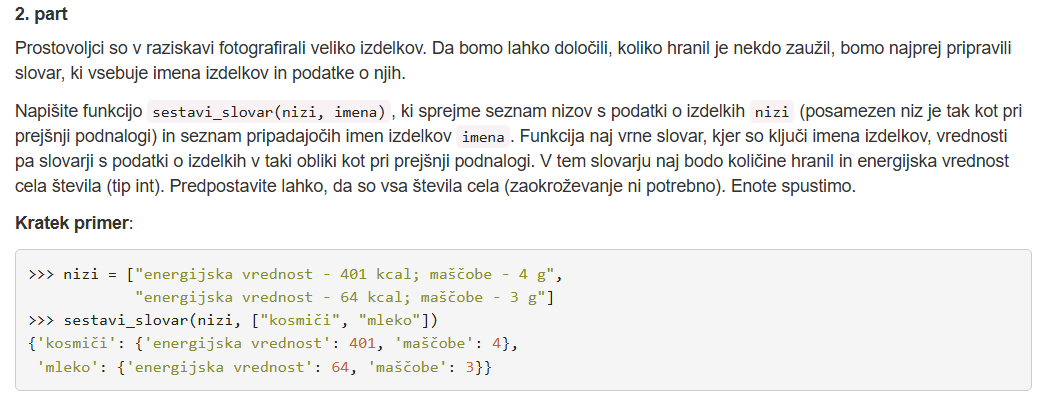

In [8]:
# to je naloga kjer iz dveh (vzporednih) seznamov naredimo en slovar
# primera:
nizi = [
    "energijska vrednost - 401 kcal; maščobe - 4 g",
    "energijska vrednost - 64 kcal; maščobe - 3 g"
]

imena = ["kosmiči", "mleko"] # torej nizi[0] in imena[0] pašeta skupaj - imata skupen indeks


def sestavi_slovar(nizi, imena): # slovar[imena[i]] = izdelek(nizi[i]) ... i-temu ključu pripada i-ta vrednost
    slovar = {}

    for i in range(len(nizi)): # range ker gremo po indeksih od 0 do konca
        podatki = izdelek(nizi[i])

        for kljuc in podatki:
            podatki[kljuc] = int(podatki[kljuc].split()[0])

        slovar[imena[i]] = podatki # npr. slovar = {"kosmiči" : podatki}

    return slovar

print(sestavi_slovar(nizi, imena))

# uradna rešitev:

def sestavi_slovar(nizi, imena):
    slovar = {}

    for i in range(len(nizi)):
        podatki_izdelka = izdelek(nizi[i])

        for kljuc, vrednost in podatki_izdelka.items(): # .items() avtomatsko naredi kljuc, vrednost
            # moramo pa napisati kljuc, vrednost da gre cez oba, drugace gre samo cez kljuc
            podatki_izdelka[kljuc] = int(vrednost.split()[0].strip())

        slovar[imena[i]] = podatki_izdelka
    
    return slovar

# for x in slovar - gre cez kljuce
# for x in slovar.values() - gre cez vrednosti
# for kljuc, vrednost in slovar.items() - gre cez oboje hkrati

{'kosmiči': {'energijska vrednost': 401, 'maščobe': 4}, 'mleko': {'energijska vrednost': 64, 'maščobe': 3}}


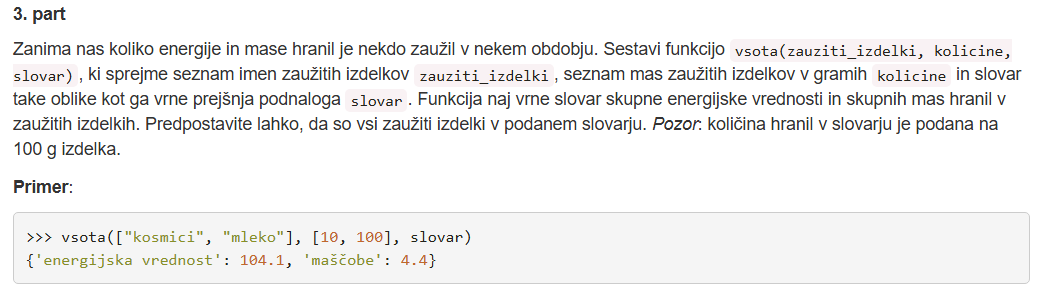

In [9]:
zauziti_izdelki = ["kosmiči", "mleko"]
kolicine = [10, 100] # v gramih
slovar = sestavi_slovar(nizi, imena) # slovar iz 2. podnaloge, kolicina je na 100g

def vsota(zauziti_izdelki, kolicine, slovar):
    slovar_pregleda = {"energijska vrednost" : 0, "maščobe" : 0}

    for i in range(len(zauziti_izdelki)):
        energija = slovar[zauziti_izdelki[i]]["energijska vrednost"] # to vrne 401 za i = 0
        slovar_pregleda["energijska vrednost"] += energija*(kolicine[i]/100)
        maščobe = slovar[zauziti_izdelki[i]]["maščobe"]
        slovar_pregleda["maščobe"] += maščobe*(kolicine[i]/100)

    return slovar_pregleda

print(vsota(zauziti_izdelki, kolicine, slovar))

# uradna rešitev: BOLJŠA
def vsota(zauziti_izdelki, mase, slovar):
    skupni_slovar = {}

    for i in range(len(zauziti_izdelki)):
        izdelek = zauziti_izdelki[i]
        masa = mase[i]
        for kolicina, vrednost in slovar[izdelek].items():
            skupni_slovar[kolicina] = skupni_slovar.get(kolicina, 0) + vrednost / 100 * masa

    return skupni_slovar

{'energijska vrednost': 104.1, 'maščobe': 3.4}


#### 2. naloga: množenje

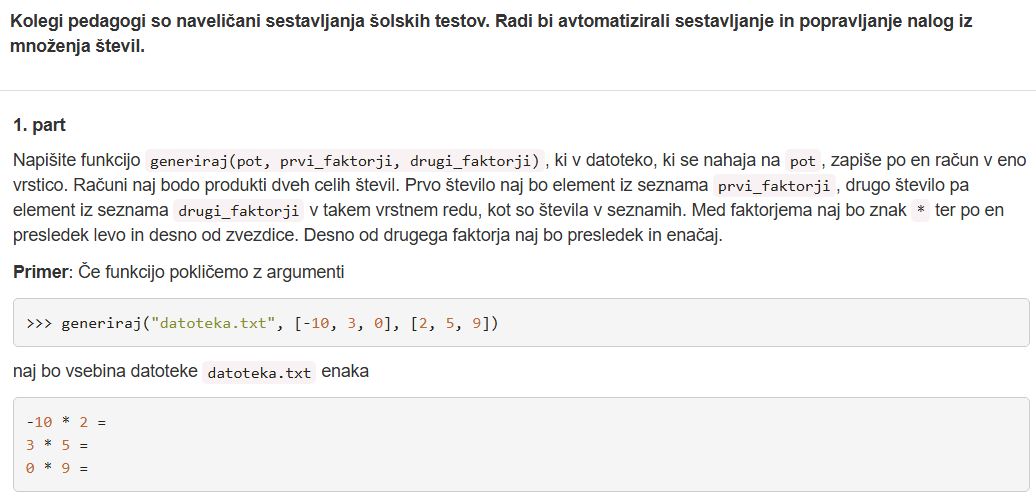

In [10]:
pot = "datoteka.txt" # niz, ime datoteke
prvi_faktorji = [-10, 3, 0] # seznam
drugi_faktorji = [2, 5, 9]

def generiraj(pot, prvi_faktorji, drugi_faktorji):
        with open(pot, "w", encoding="utf-8") as f:

            for i in range(len(prvi_faktorji)):
                racun = str(prvi_faktorji[i]) + " * " + str(drugi_faktorji[i]) + " =\n"
                f.write(racun)

# izpis kaj ta koda naredi:

generiraj(pot, prvi_faktorji, drugi_faktorji)

with open(pot, "r", encoding="utf-8") as f:
    print(f.read())

-10 * 2 =
3 * 5 =
0 * 9 =



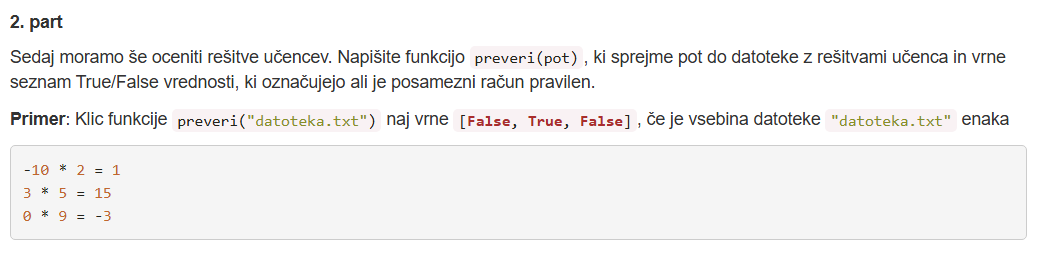

In [11]:
def preveri(pot):
    pravilno_reseno = []

    with open (pot, "r", encoding="utf-8") as f:
        for vrstica in f:
            racun, odgovor = vrstica.split("=").strip() # vrstica.split nredi to: ["-10 * 2 ", " 1"], točno dva niza, ju lahko shranimo skupaj
            stevili = racun.split("*")
            prvi_faktor = int(stevili[0])
            drugi_faktor = int(stevili[1])
            pravilen_rezultat = prvi_faktor * drugi_faktor

            odgovor = int(odgovor)

            pravilno_reseno.append(pravilen_rezultat == odgovor)

        return pravilno_reseno

print(preveri(pot))

# uradna rešitev - boljša:
def preveri(pot):
    pravilno_reseno = []

    with open (pot, "r", encoding="utf-8") as f:
        for vrstica in f:
            seznam = vrstica.strip().split() # vsi členi so ločeni z presledki, tako jih ločimo: ["3", "*", "5", "=", "15"]
            prvi_faktor = int(seznam[0]) # prvi člen, i=1 je *
            drugi_faktor = int(seznam[2]) # i = 2 je drugi faktor
            resitev = int(seznam[4])
            prava_resitev = prvi_faktor * drugi_faktor

            pravilno_reseno.append(resitev == prava_resitev)

        return pravilno_reseno

print(preveri(pot))

AttributeError: 'list' object has no attribute 'strip'

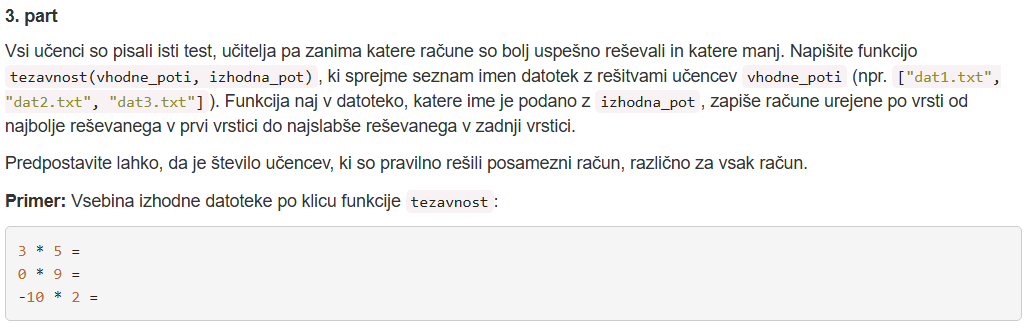

In [ ]:
def tezavnost(vhodne_poti, izhodna_pot):
    racuni = []
    vsota_prav_resenih = []

    with open(vhodne_poti[0], mode="r", encoding="utf-8")as vhodna:
        for vrstica in vhodna:
            racuni.append(vrstica)
            vsota_prav_resenih.append(0)

    for pot in vhodne_poti:
        pravilno_reseno = preveri(pot)
        for j in range(len(pravilno_reseno)):
            if pravilno_reseno[j]:
                vsota_prav_resenih[j] += 1

    with open(izhodna_pot, mode="w", encoding="utf-8") as izhodna:
        for k in range(len(vhodne_poti), -1, -1):
            for l in range(len(vsota_prav_resenih)):
                if vsota_prav_resenih[l] == k:
                    racun = racuni[l]
                    indeks_enacaja = racun.index("=")
                    izhodna.write(racun[:indeks_enacaja+1] + "\n")

#### 3. naloga: ocene

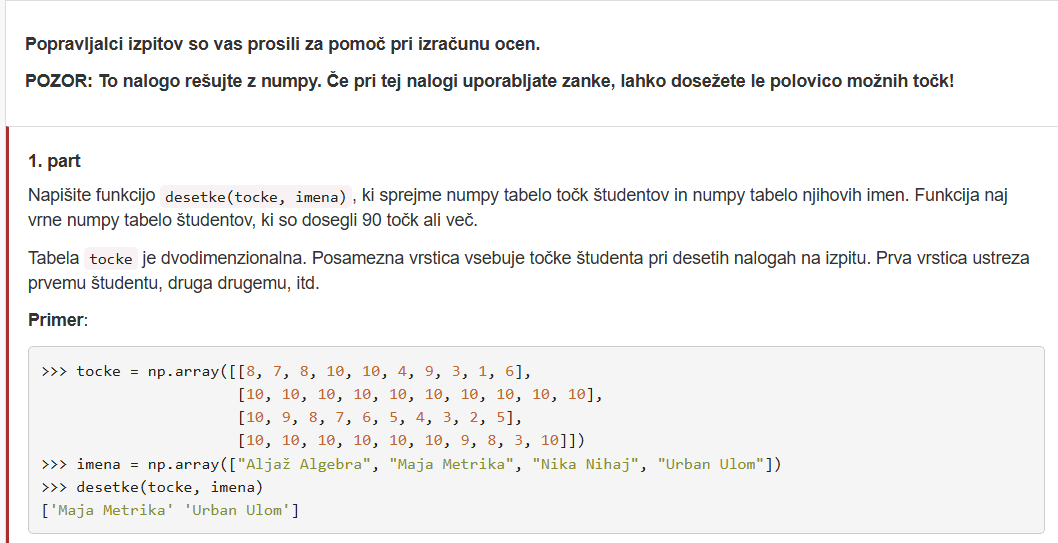

In [ ]:
import numpy as np

tocke = np.array([
    [8, 7, 8, 10, 10, 4, 9, 3, 1, 6],
    [10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
    [10, 9, 8, 7, 6, 5, 4, 3, 2, 5],
    [10, 10, 10, 10, 10, 10, 10, 9, 8, 3]
])

imena = np.array([
    "Aljaž Algebra",
    "Maja Metrika",
    "Nika Nihaj",
    "Urban Ulom"
])

def desetke(tocke, imena):
    vsote = np.sum(tocke, axis=1) # sesteje elemente po vsaki vrstici in vrne eno vsoto za vsakega studenta
    # zgleda zdaj prib tako: array([66, 100, 59, 90])
    # vsote >= 90 - vrne [false, true, false, true], to je boolean maska
    return imena[vsote >= 90]

print(desetke(tocke, imena))

['Maja Metrika' 'Urban Ulom']


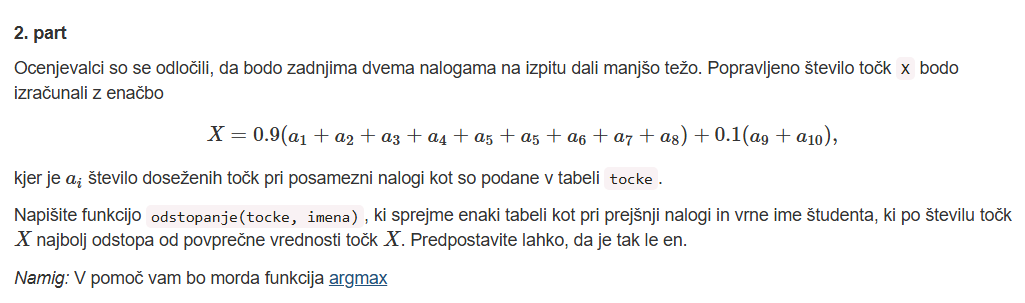

In [ ]:
import numpy as np # ce je zagnan v kaksnem bloku prej ni spet treba pisat

def odstopanje(tocke, imena):
    X = 0.9 * np.sum(tocke[:, 0:8], axis=1) + 0.1 * np.sum(tocke[:, 8:10], axis=1) # tocke[vrstice, stolpci], : -> vse vrstice, 0:8 -> prvih 8 stolpcev (od 0 do indeksa 7)
    # x ni stevillka, je np.array: array([X_prvega, X_drugega, X_tretjega, X_cetrtega])
    povprecje = np.average(X) # vrne eno povrp vrednost
    odklon_povpr = np.abs(X - povprecje)
    i_max_odklona = np.argmax(odklon_povpr) # np.max bi vrnil vrednost, np.argmax pa indeks od max
    
    return imena[i_max_odklona]

print(odstopanje(tocke, imena))

Nika Nihaj


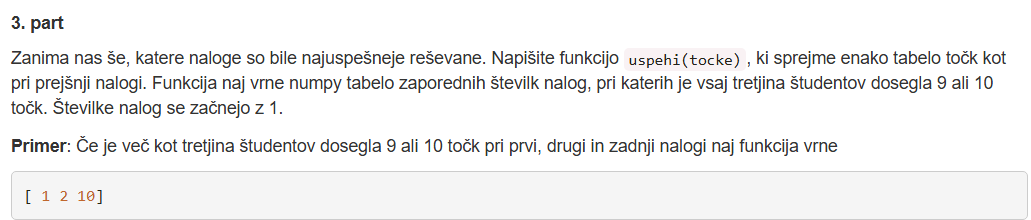

In [ ]:
def uspehi(tocke):
    maska = tocke > 8 # to ze vrne true/false tabelo, vse pise, true in false, ohrani lokacijo
    # ne rabi pisati: >= 9, samo > 8 lahko
    st_studentov = np.sum(maska, axis=0) # rezultat: [3, 2, 1, 4...] -> prvi stolpec ima 3 true, drugi 2...
    # true = 1, false = 0, samo seštejemo po stolpcih: axis=0
    pogoj = st_studentov > len(tocke)/3 # ce recimo rabimo vec kot tretjino...imamo [true, true, false,...]
    i_true = np.flatnonzero(pogoj) + 1  # nov np ukaz, dobimo indekse kjer != 0, torej kjer je true: [0, 1, 3]
    # indeksiranje se začne z 0, naloge pa z 1., indeks nal 1 mora biti 1, torej + 1

    return i_true

print(uspehi(tocke))

[1 2 3 4 5 6 7 8]


## 2. izpit 23/24

#### 1. naloga: Obdelava besedila

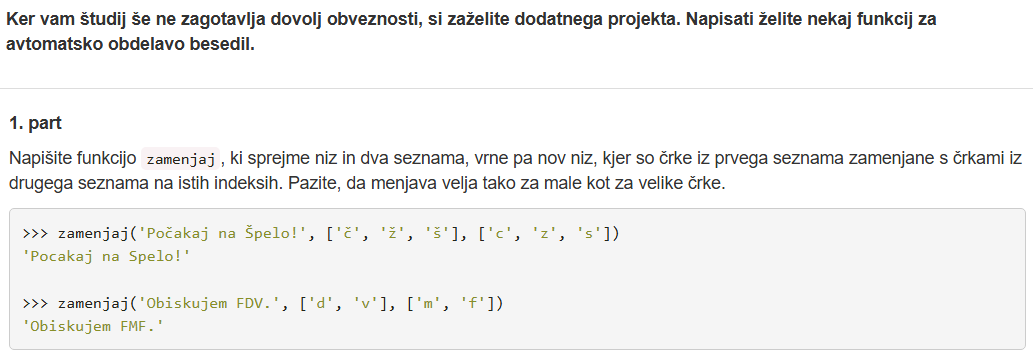

In [ ]:
niz = "Počakaj na Špelo"
sez1 = ["č", "ž", "š"]
sez2 = ["c", "z", "s"]

def zamenjaj(niz, sez1, sez2):
    for i in range(len(sez1)):
        niz = niz.replace(sez1[i], sez2[i])
        niz = niz.replace(sez1[i].upper(), sez2[i].upper())

    return niz

print(zamenjaj(niz, sez1, sez2))

Pocakaj na Spelo


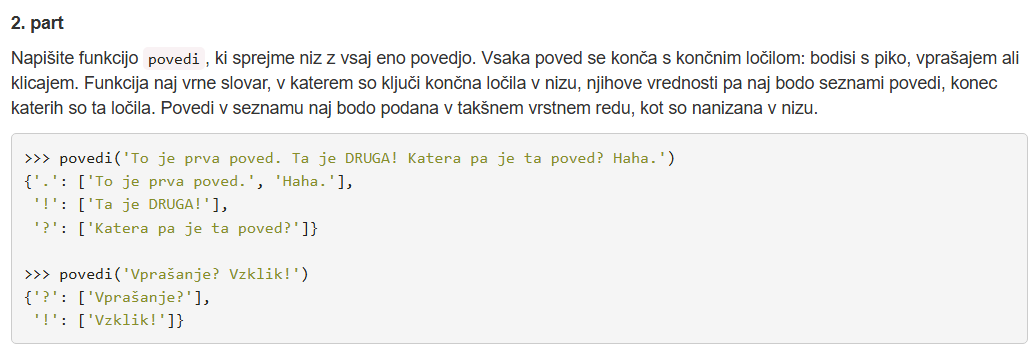

In [ ]:
niz = "To je prva poved. Ta je DRUGA! Katera pa je ta poved? Haha."

def povedi(niz):
    slovar = {}
    poved = ""

    for znak in niz:
        poved += znak

        if znak in [".", "!", "?"]:
            if znak not in slovar:
                slovar[znak] = [poved.strip()]
            else:
                slovar[znak].append(poved.strip())
            poved = ""

    return slovar

print(povedi(niz))

{'.': ['To je prva poved.', 'Haha.'], '!': ['Ta je DRUGA!'], '?': ['Katera pa je ta poved?']}


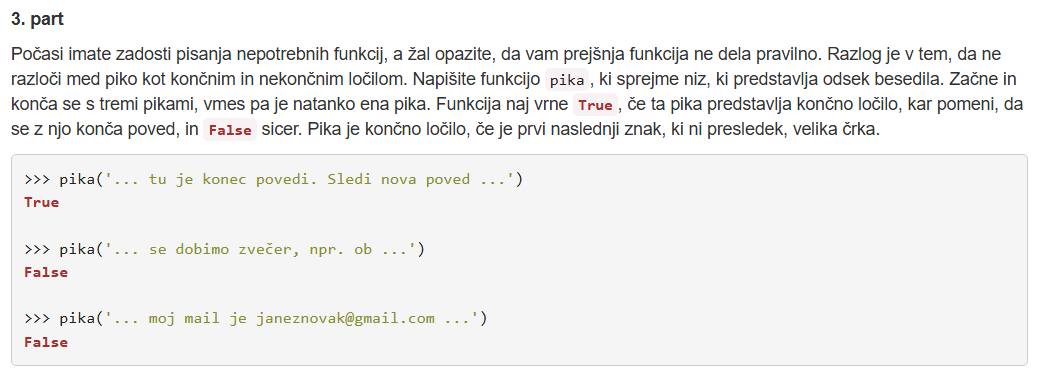

In [ ]:
odsek = "... tu je konec povedi. Sledi nova poved ..."

def pika(odsek):
    odsek = odsek[4 : -4]
    i = odsek.index(".") # indeks notranje pike

    for j in range(i+1, len(odsek)):
        znak = odsek[j]
        if znak != " ":
            if znak.isupper():
                return True
            else:
                return False

print(pika(odsek))

True


#### 2. naloga: LPP

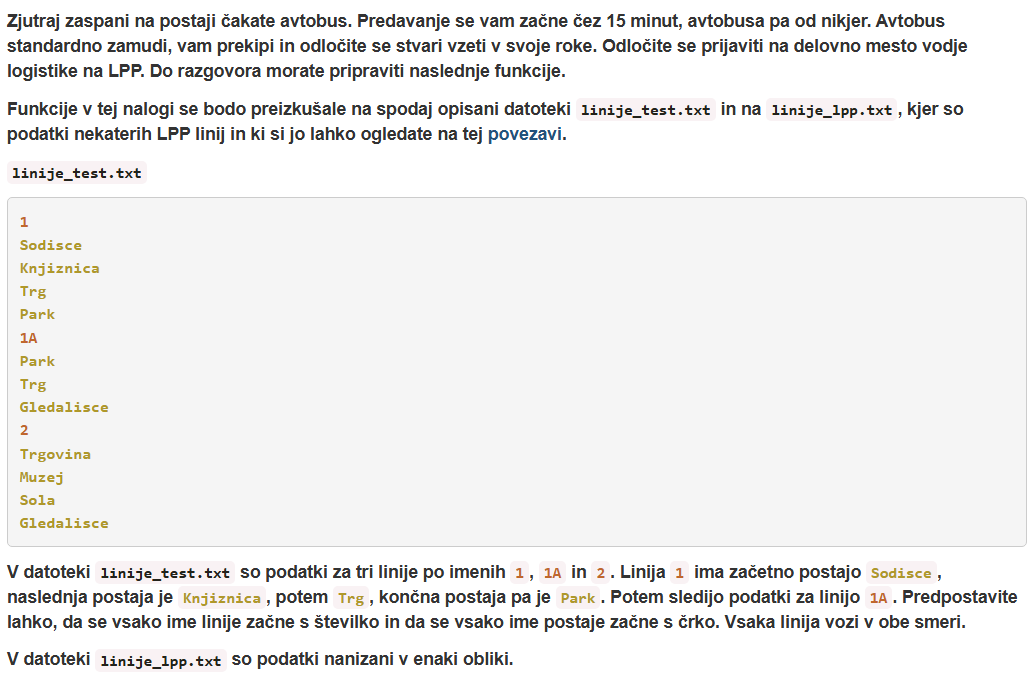

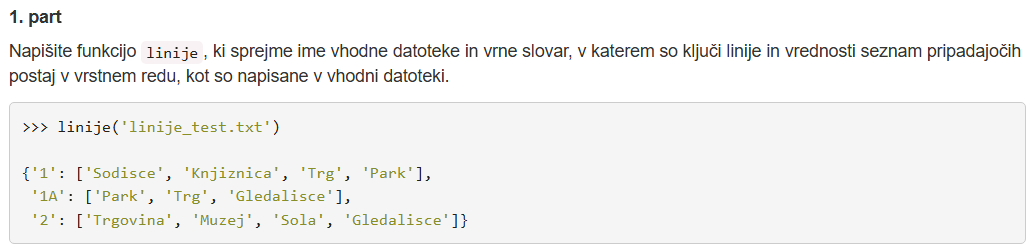

In [ ]:
def linije(ime_vhodne):
    with open(ime_vhodne, 'r', encoding='utf-8') as dat:
        vrstice = dat.readlines()
    slo = {}
    for vrstica in vrstice:
        vrstica = vrstica.strip()
        if vrstica[0].isnumeric(): # if vrstica[0] in ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']: 
            linija = vrstica
            slo[linija] = []
        else:
            slo[linija].append(vrstica)
    return slo

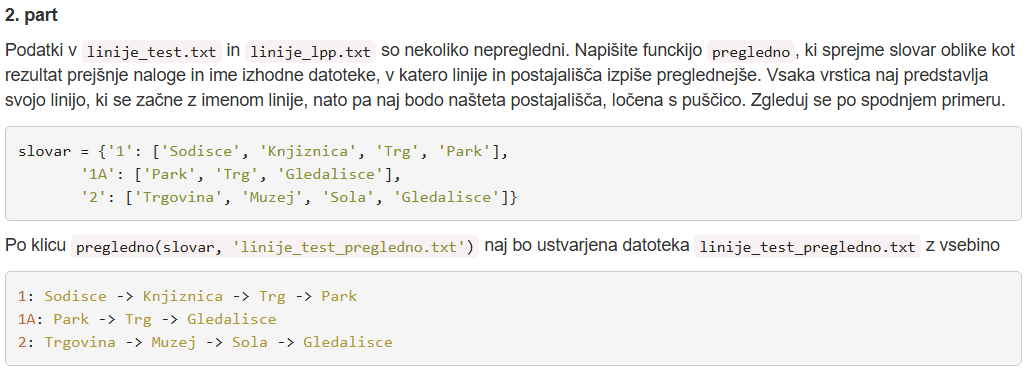

In [ ]:
def pregledno(slo, ime_izhoda):
    with open(ime_izhoda, 'w', encoding='utf-8') as dat:
        for (linija, postaje) in slo.items():
            dat.write(linija + ': ')        # dat.write(f'{linija}: ')
            for postaja in postaje[:-1]:
                dat.write(postaja + ' -> ') # dat.write(f'{postaja} -> ')
            dat.write(postaje[-1] + '\n')   # dat.write(f'{postaje[-1]}\n')

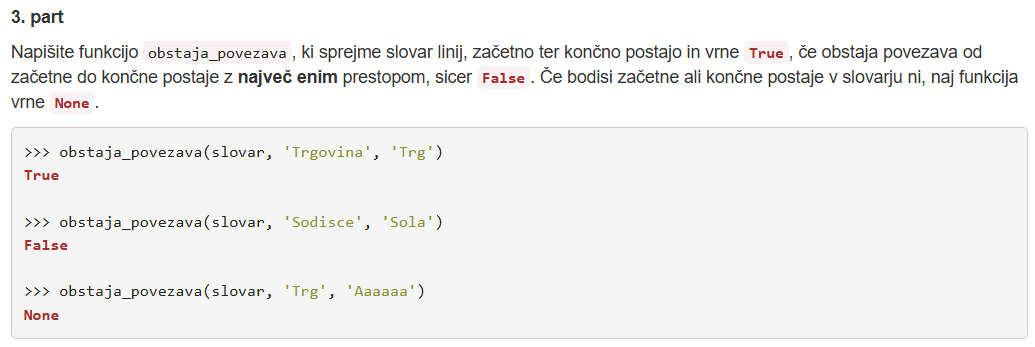

In [ ]:
def obstaja_povezava(slo, zacetna, koncna):
    vse_postaje = []
    for postaje in slo.values():
        vse_postaje += postaje
    if (zacetna not in vse_postaje) or (koncna not in vse_postaje):
        return None
    for postaje in slo.values():
        if zacetna in postaje:
            for prestopna_postaja in postaje:
                for postaje in slo.values():
                    if (prestopna_postaja in postaje) and (koncna in postaje):
                        return True
    return False

#### 3. naloga: Finance

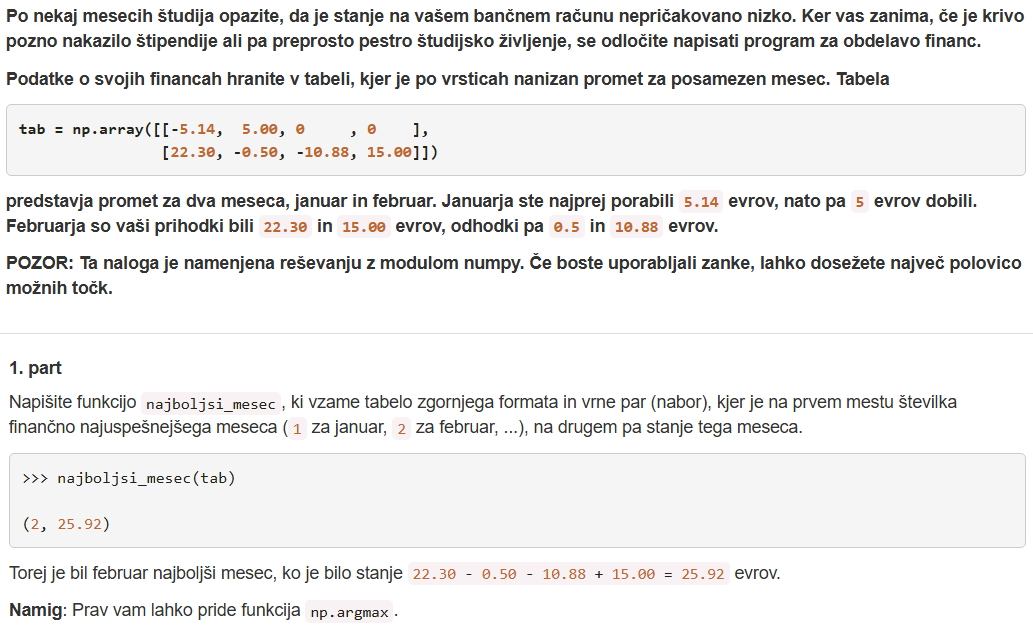

In [ ]:
import numpy as np

tab = np.array([[-5.14,  5.00, 0     , 0    ], 
                [22.30, -0.50, -10.88, 15.00]])

def najbolsi_mesec(tab):
    vsote = np.sum(tab, axis=1) # stanje za vsak mesec, npr: (20, 0, -5,...)
    max_vsota = np.argmax(vsote) # indeks max vrednosti

    return (max_vsota + 1, vsote[max_vsota])


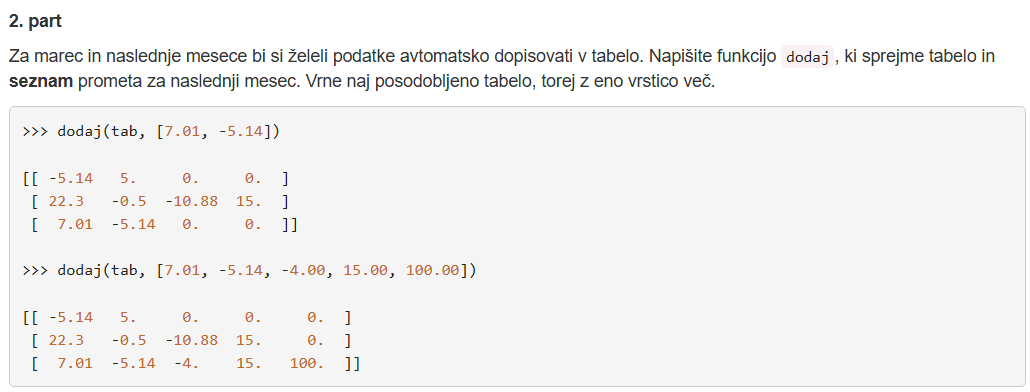

In [ ]:
seznam = [7.01, -5.14]

def dodaj(tab, seznam):
    (n, m) = np.shape(tab)
    novo_st_vrstic = n + 1
    novo_st_stolpcev = max(m, len(seznam))
    nova_tab = np.zeros((novo_st_vrstic, novo_st_stolpcev))
    nova_tab[:n, :m] = tab # tabela[vrstice, stolpci], [:n, :m] -> od začetka do n (brez n) - od indeksa 0 do n-1
    nova_tab[n, :len(seznam)] = seznam # [n, ...] samo vrstica n, lahko tudi napišemo -1, kakor zadnja vrstica

    return nova_tab

print(dodaj(tab, seznam))

[[ -5.14   5.     0.     0.  ]
 [ 22.3   -0.5  -10.88  15.  ]
 [  7.01  -5.14   0.     0.  ]]


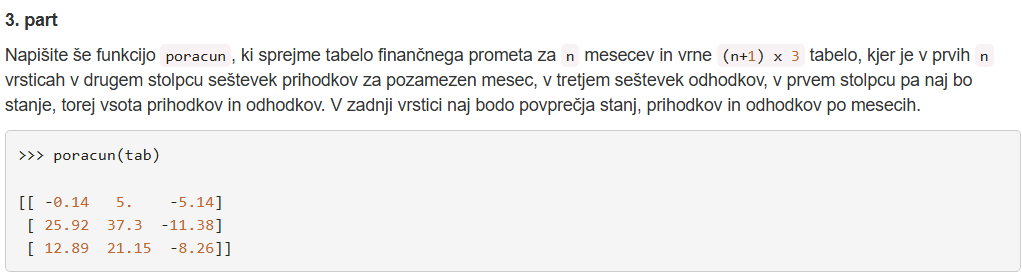

In [ ]:
def poracun(tab):
    (n, m) = np.shape(tab) # označimo da je n št vrstic (in m stolpec (ne bomo rabil))
    tab2 = np.zeros((n+1, 3))
    prihodki_tab = np.where(tab > 0, tab, 0) # np.where(pogoj, vrednost_če_pogoj_velja, vrednost_če_ne_velja)
    odhodki_tab = np.where(tab < 0, tab, 0) # ustvari tabelo odhodkov

    prihodki = np.sum(prihodki_tab, axis=1)
    odhodki = np.sum(odhodki_tab, axis=1)
    stanje = prihodki + odhodki

    tab2[:n, 0] = stanje # prvih n (brez n, n-ta je še prazna) vrstic v prvem stolpu imamo stanje
    tab2[:n, 1] = prihodki
    tab2[:n, 2] = odhodki

    tab2[-1, :] = np.average(tab2[:n, :], axis=0) # zadnja vrstica, vsi trije stolpci, average od 
    # vseh vrstic razen zadnje, celoten stolpec
    return tab2

print(poracun(tab))

[[ -0.14   5.    -5.14]
 [ 25.92  37.3  -11.38]
 [ 12.89  21.15  -8.26]]


## 3. izpit 23/24

#### 1. naloga: Razgovor

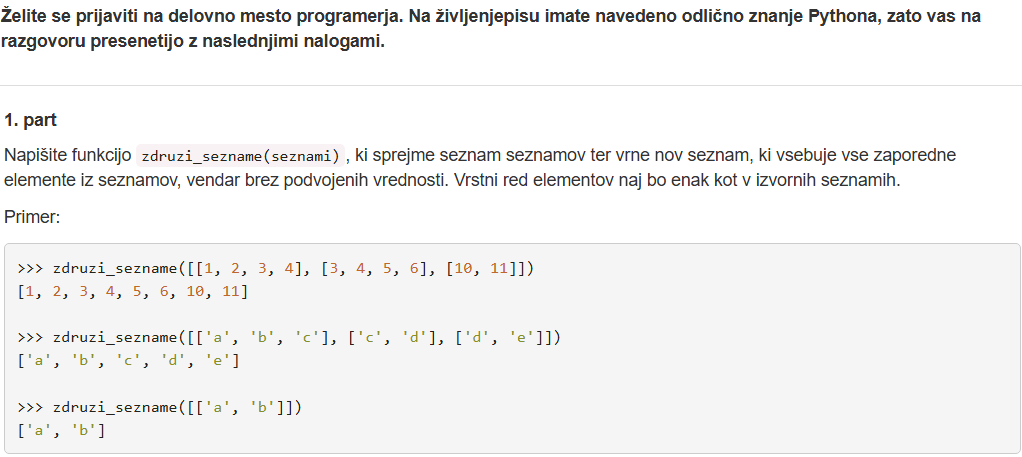

In [ ]:
seznami = [[1, 2, 3, 4], [3, 4, 5, 6], [10, 11]]

def zdruzi_sezname(seznami):
    nov_sez = []

    for seznam in seznami:
        for element in seznam:
            if element not in nov_sez:
                nov_sez.append(element)
    
    return nov_sez

print(zdruzi_sezname(seznami))

[1, 2, 3, 4, 5, 6, 10, 11]


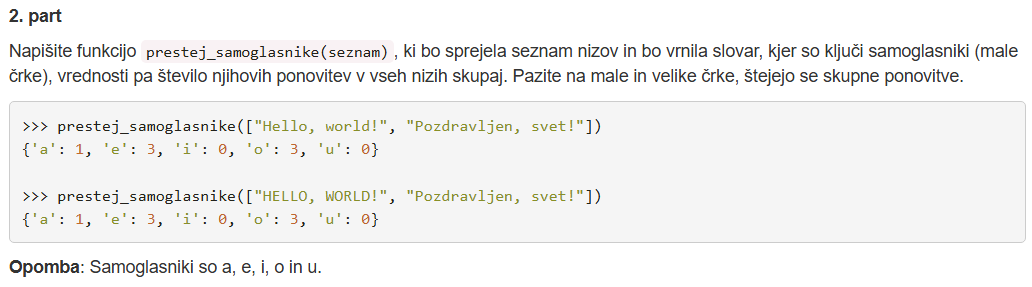

In [ ]:
seznam = ["Hello, world!", "Pozdravljen, svet!"]

def prestej_samoglasnike(seznam):
    slovar = {"a":0, "e":0, "i":0, "o":0, "u":0}
    for niz in seznam:
        for znak in niz.lower():
            if znak in ["a", "e", "i", "o", "u"]:
                slovar[znak] += 1
            
    return slovar

print(prestej_samoglasnike(seznam))

{'a': 1, 'e': 3, 'i': 0, 'o': 3, 'u': 0}


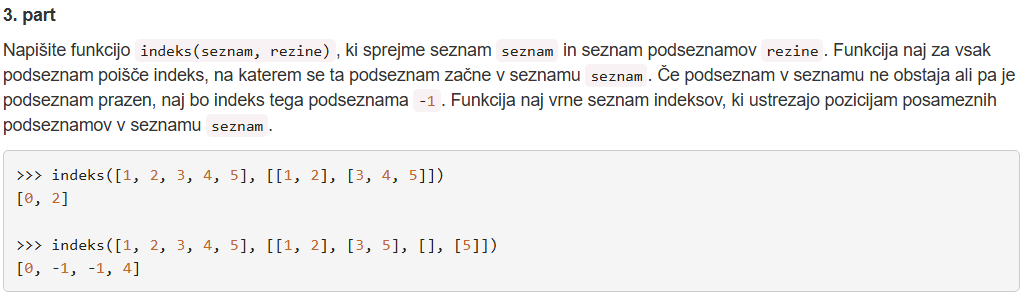

In [ ]:
seznam = [1, 2, 3, 4, 5] # seznam
rezine = [[1, 2], [3, 4, 5]] # seznam podseznamov

def indeks(seznam, rezine):
    sez_indeksov = []
    for podsez in rezine:
        seznam[i : i + len(podsez)] == podsez


#### 2. naloga: Drevesna debla

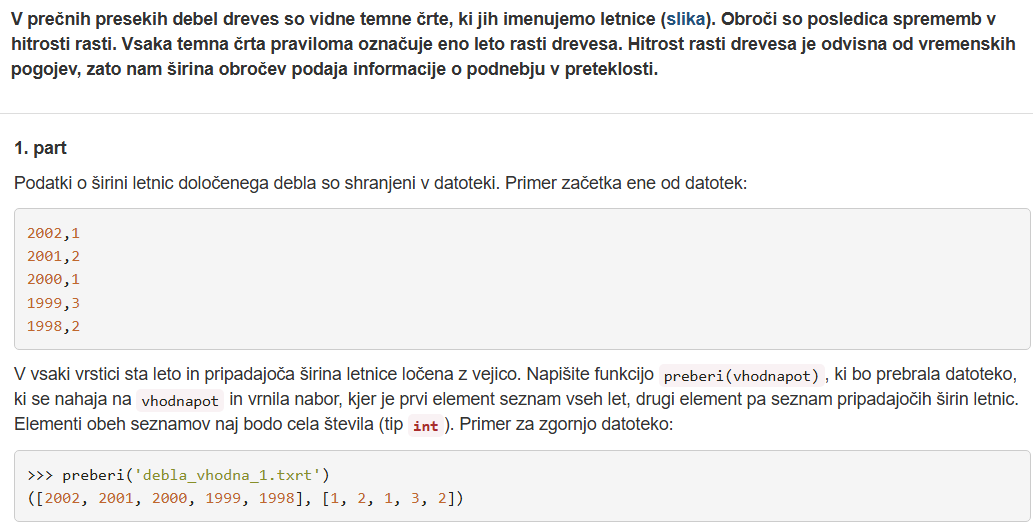

In [ ]:
def preberi(vhodnapot):
    leta = []
    sirine = []

    with open(vhodnapot, mode='r', encoding='utf-8') as f:
        for vrstica in f:
            vrednosti = vrstica.strip().split(',')
            leta.append(int(vrednosti[0]))
            sirine.append(int(vrednosti[1]))
    return leta, sirine

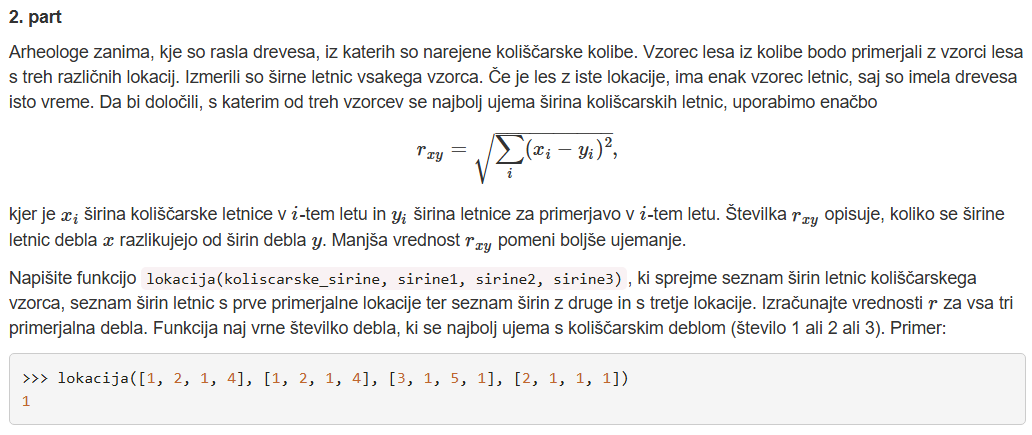

In [ ]:
def odstopanje(meritve1, meritve2):
    vsota = 0
    for i in range(len(meritve1)):
        vsota += (meritve1[i] - meritve2[i])**2
    return vsota ** 0.5


def lokacija(koliscarske_sirine, sirine1, sirine2, sirine3):
    odstopanje1 = odstopanje(koliscarske_sirine, sirine1)
    odstopanje2 = odstopanje(koliscarske_sirine, sirine2)
    odstopanje3 = odstopanje(koliscarske_sirine, sirine3)
    if odstopanje1 < odstopanje2 and odstopanje1 < odstopanje3:
        return 1
    elif odstopanje2 < odstopanje1 and odstopanje2 < odstopanje3:
        return 2
    else:
        return 3

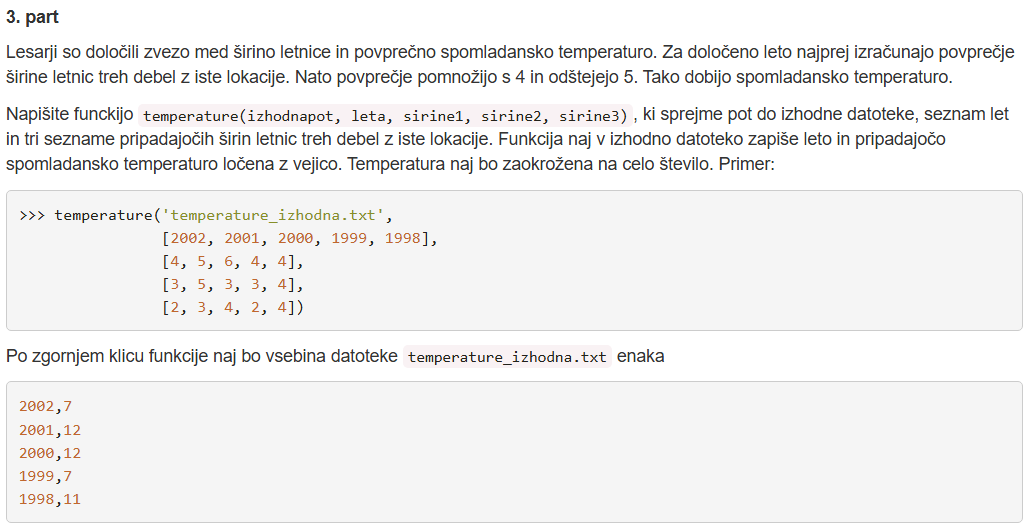

In [ ]:
def temperature(izhodnapot, leta, sirine1, sirine2, sirine3):
    with open(izhodnapot, mode='w', encoding='utf-8') as f:
        for i in range(len(leta)):
            povprecje = (sirine1[i] + sirine2[i] + sirine3[i]) / 3
            temp = 4 * povprecje - 5
            f.write(str(leta[i]) + ',' + str(round(temp)) + '\n')   

#### 3. naloga: Meritve

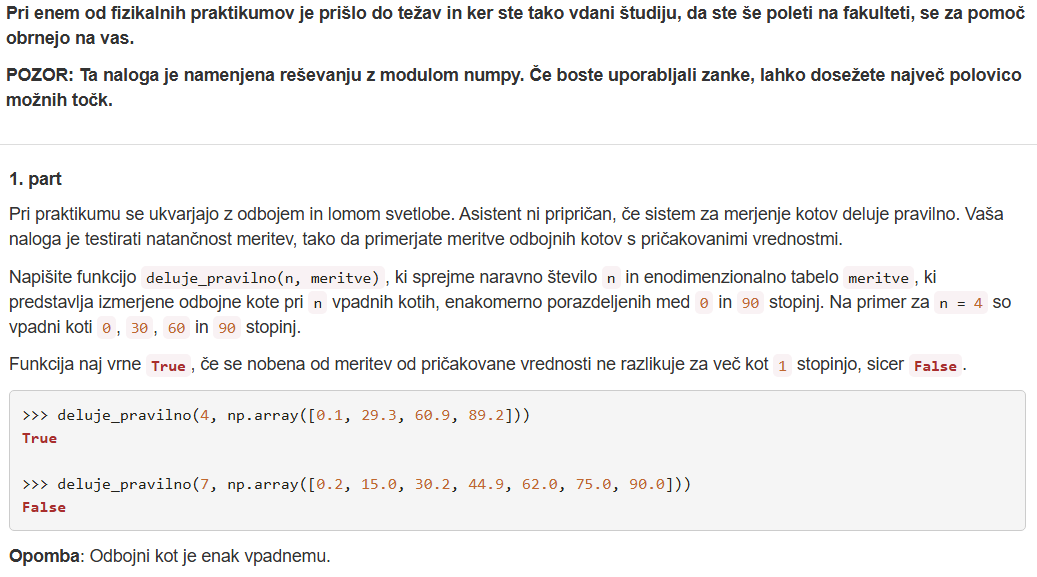

In [13]:
import numpy as np

n = 4
meritve = np.array([0.1, 29.3, 60.9, 89.2])

def deluje_pravilno(n, meritve):
    pravilna_tabela = np.linspace(0, 90, n) #np.linspace(začetek, konec, število_elementov) - ustvari tabelo
    odstopanja = np.abs(meritve - pravilna_tabela)

    return np.all(odstopanja <= 1) # np.all(pogoj) vrne samo true/false, če je en false vrne false
 
print(deluje_pravilno(n, meritve))

True


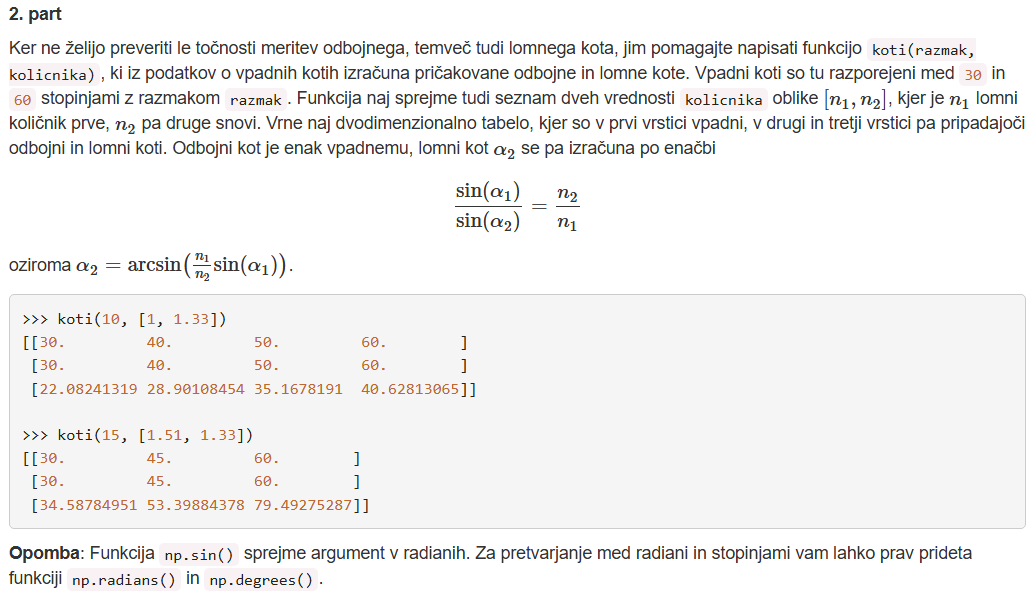

In [ ]:
razmak = 10 # koti od 30 do 60 imajo razmak 10
kolicnika = [1, 1.33]

def koti(razmak, kolicnika):
    vpadni_koti = np.arange(30, 60 + razmak, razmak) #np.arange(začetek, konec, korak), tudi ustvari 1d tabelo le da je 3. argument korak
    odbojni_koti = vpadni_koti # oba v stopinjah

    n1, n2 = kolicnika
    vpadni_rd = np.radians(vpadni_koti)  # moramo pretvorit v radiane
    vpadni_sin = np.sin(vpadni_rd)
    vpadni_kol = n1/n2 * vpadni_sin
    lomni_koti = np.arcsin(vpadni_kol) # vrne v rd
    lomni_degr = np.degrees(lomni_koti)

    return np.vstack([vpadni_koti, odbojni_koti, lomni_degr]) # np.vstack - vertikalno stackanje, navpično zalaganje

print(koti(razmak, kolicnika))

# uradne resitve:

def koti(razmak, kolicnika):
    vpadni = np.arange(30, 60 + razmak, razmak)
    odbojni = vpadni
    [n1, n2] = kolicnika
    lomni = np.arcsin((n1 / n2) * np.sin(np.radians(vpadni))) # vrne lomnega v rd
    lomni = np.degrees(lomni)
    return np.vstack([vpadni, odbojni, lomni])

[[30.         40.         50.         60.        ]
 [30.         40.         50.         60.        ]
 [22.08241319 28.90108454 35.1678191  40.62813065]]


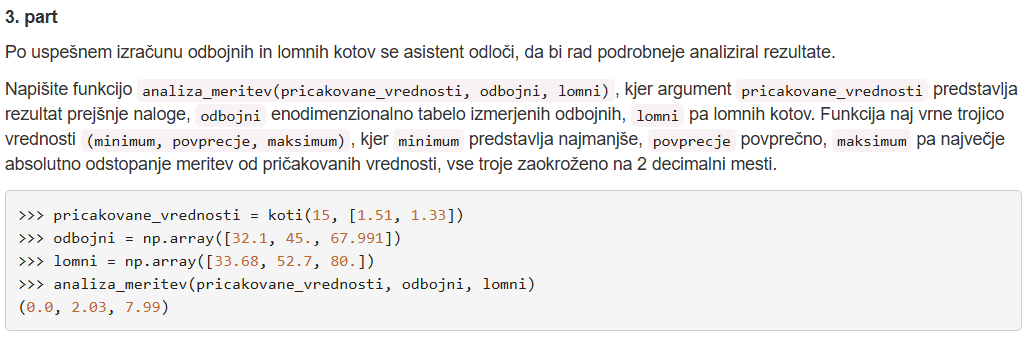

In [22]:
razmak = 15
kolicnika = [1.51, 1.33]
pricakovane_vrednosti = koti(razmak, kolicnika) # ima 3 vrstice - 0: pricakovani vpadni, 1: pricakovani odbojni, 2: pricak. lomni
odbojni = np.array([32.1, 45., 67.991])
lomni = np.array([33.68, 52.7, 80])

def analiza_meritev(pricakovane_vrednosti, odbojni, lomni):
    odbojni_odstopanje = np.abs(odbojni - pricakovane_vrednosti[1, :])
    lomni_odstopanje = np.abs(lomni - pricakovane_vrednosti[2, :])

    skupaj = np.append(odbojni_odstopanje, lomni_odstopanje) # lahko damo vse skupaj v eno tabelo, ker nas ne zanima posebej za odbojni/lomni kot

    minimum = round(np.min(skupaj), 2) # round(.., 2) -> zaokorozi ... na  2 decimalki
    maksimum = round(np.max(skupaj), 2)
    povprecje = round(np.average(skupaj), 2)

    return (minimum, povprecje, maksimum) # np.array([min, povprecje, max]) vrne array, mi zelimo pa tuple: (min, avg, max) - trojico

print(analiza_meritev(pricakovane_vrednosti, odbojni, lomni))

(np.float64(0.0), np.float64(2.03), np.float64(7.99))


## 1. izpit 24/25

#### 1. naloga: Pokvarjen pomnilnik

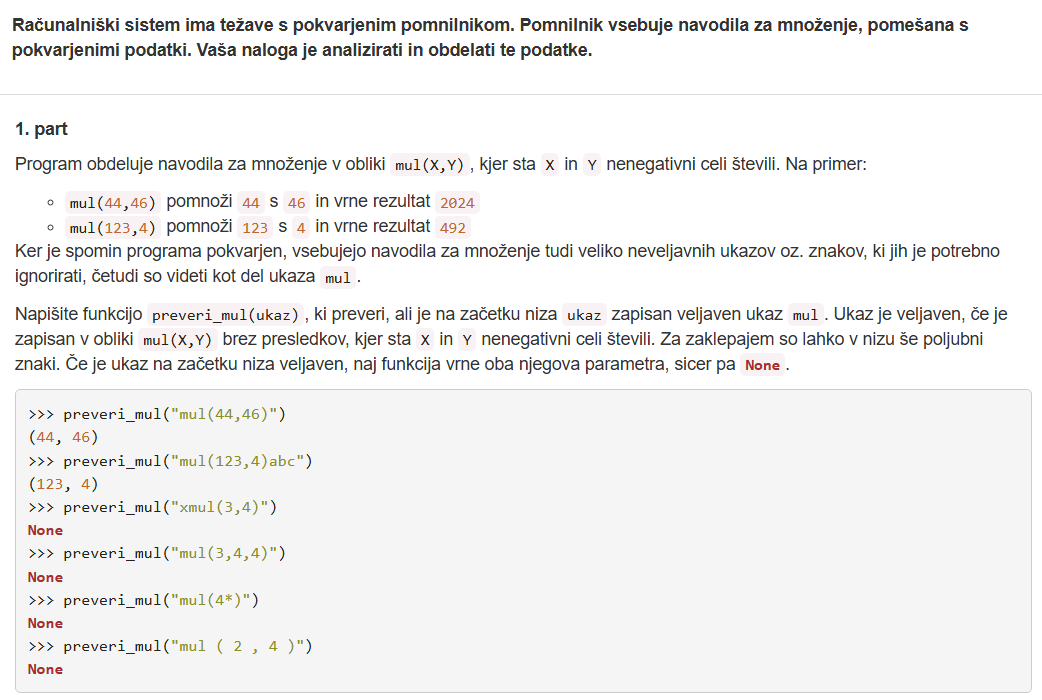

In [ ]:
ukaz = "mul(44,46)abc"

def preveri_mul(ukaz):
    if ukaz.startswith("mul("):
        i = ukaz.find(")") # i je indeks zaklepaja
        if i >= 0:
            par = ukaz[4 : i].split(",")
            if len(par) == 2 and par[0].isdigit() and par[1].isdigit(): # npr ( 4) je false, ima presledek
                return int(par[0]), int(par[1])
    #else:
    return None

print(preveri_mul(ukaz))

(44, 46)


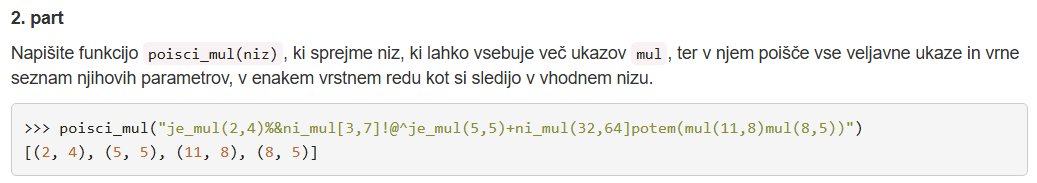

In [27]:
niz = "je_mul(2,3)%&ni_mul[3,7]!@je_mul(5,5)+ni_mul(32,64]]potem(mul(11,8)mul(8,5))"

def poisci_mul(niz):
    sez = []
    for i in range(len(niz)):
        par = preveri_mul(niz[i:])

        if par != None:
            sez.append(par)

    return sez

print(poisci_mul(niz))

[(2, 3), (5, 5), (11, 8), (8, 5)]


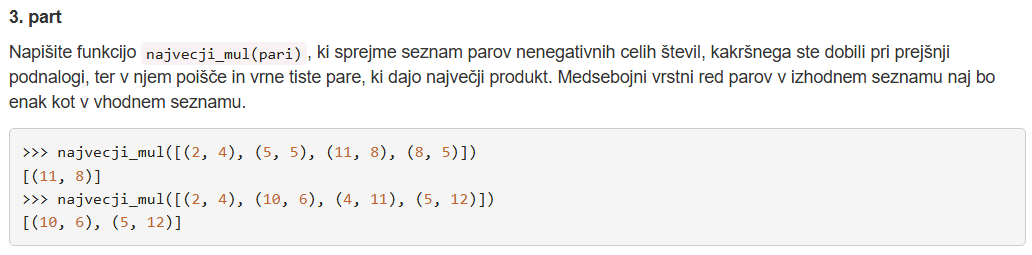

In [ ]:
pari = [(2, 3), (5, 5), (11, 8), (8, 5)]

def najvecji_mul(pari):
    produkt = 0
    sez = []
    for a, b in pari:
        p = a * b
        if  p > produkt:
            produkt = p
            sez = [(a, b)] # samo a,b mora vsebovati, stari gredo stran
        elif p == produkt:
            sez.append((a, b))

    return sez
print(najvecji_mul(pari))


[(11, 8)]


#### 2. naloga: Grda pisava

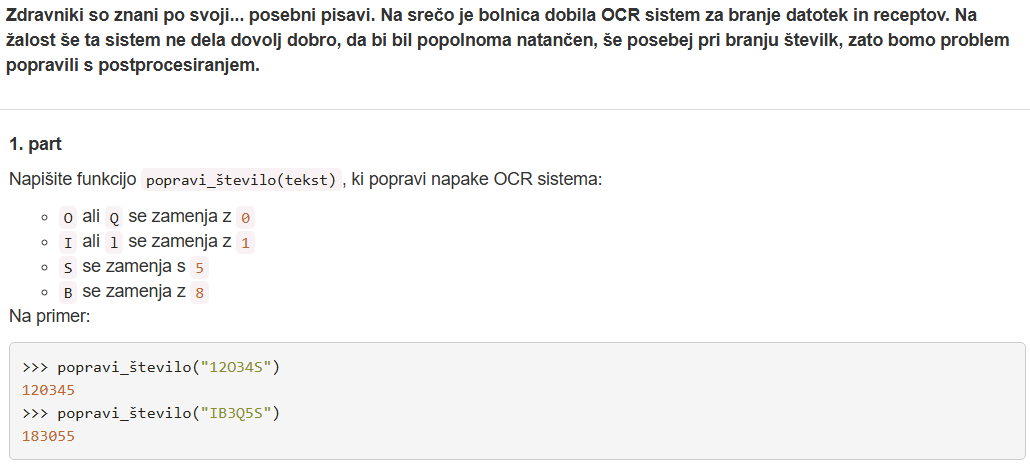

In [ ]:
tekst = "12O34S"

def popravi_stevilo(tekst):
        zamenjave = {"O" : "0",
                     "Q" : "0",
                     "I" : "1",
                     "l" : "1",
                     "S" : "5",
                     "B" : "8"}
        for kljuc, vrednost in zamenjave.items(): # daj mi vse pare (kljuc, vrednost) iz slovarja
                tekst = tekst.replace(kljuc, vrednost)

        return int(tekst)

print(popravi_stevilo(tekst))

120345


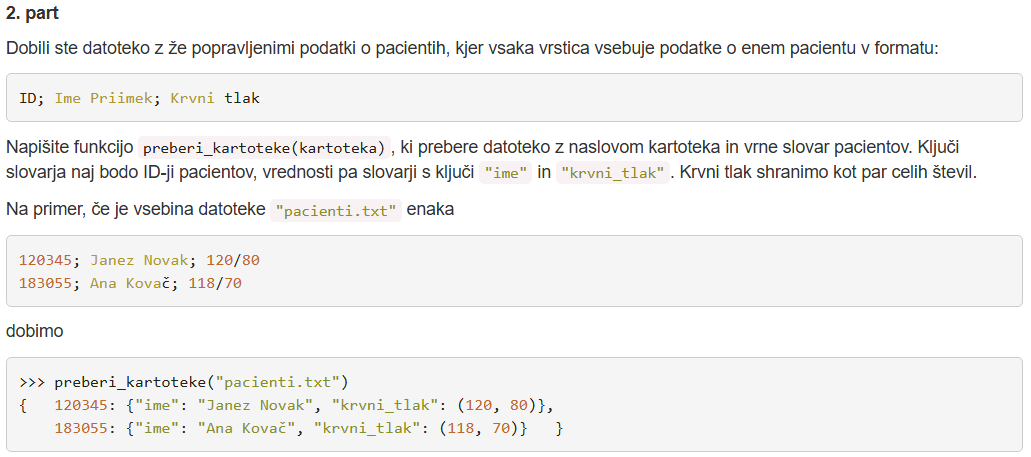

In [44]:
def preberi_kartoteko(kartoteka):
    pacienti = {}

    with open(kartoteka, "r", encoding="utf-8") as dat:
        for vrstica in dat:
            if vrstica.strip(): # preveri ce imamo prazno vrstico
                podatki = vrstica.split(";") # dobimo ["120345", " Janez Novak", " 120/80"]
                id = int(podatki[0])
                ime = podatki[1].strip() # da se znebimo presledka levo
                tlak_sp, tlak_zg = podatki[2].split("/") # tlak_sp = "120", tlak_zg = "80\n"
                tlak = int(tlak_sp), int(tlak_zg)

                pacienti[id] = {
                    "ime" : ime,
                    "krvni_tlak" : tlak
                }

        return pacienti

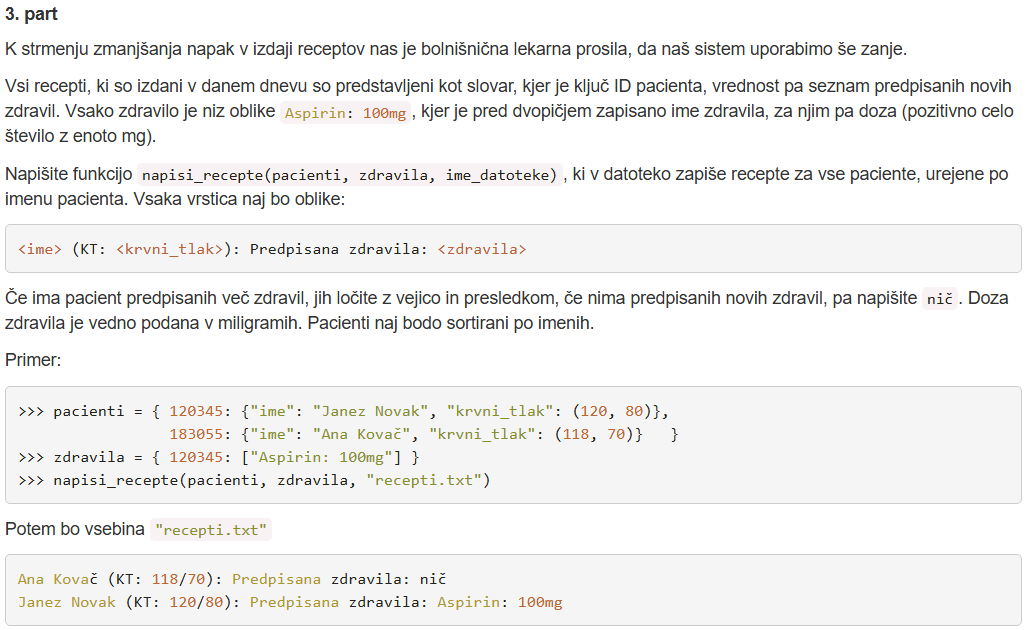

In [ ]:
def napisi_recepte(pacienti, zdravila, ime_datoteke):
    vrstice = [] # prazen seznam
    for id_pacienta, podatki in pacienti.items():
        tlak_sp, tlak_zg = podatki['krvni_tlak'] # razpakiramo tuple
        vrstica = podatki['ime'] + " (KT: " + str(tlak_sp) + "/" + str(tlak_zg) + "): Predpisana zdravila:"
        meds = zdravila.get(id_pacienta, []) # .get() vrne seznam zdravil
        if meds:
            for zdravilo in meds:
                vrstica += " " + zdravilo + "," #Janez Novak (KT: 120/80): Predpisana zdravila: Aspirin: 100mg,
        else:
            vrstica += " nič,"
        vrstica = vrstica[:-1] + "\n" # da bodo vsaka v svoji vrstici
        vrstice.append(vrstica)
    
    vrstice.sort()
    with open(ime_datoteke, 'w', encoding='utf-8') as f: # zapišemo v datoteko
        f.writelines(vrstice) # zapiše skupaj vse nize seznama

#### 3. naloga: Osnove konvolucij

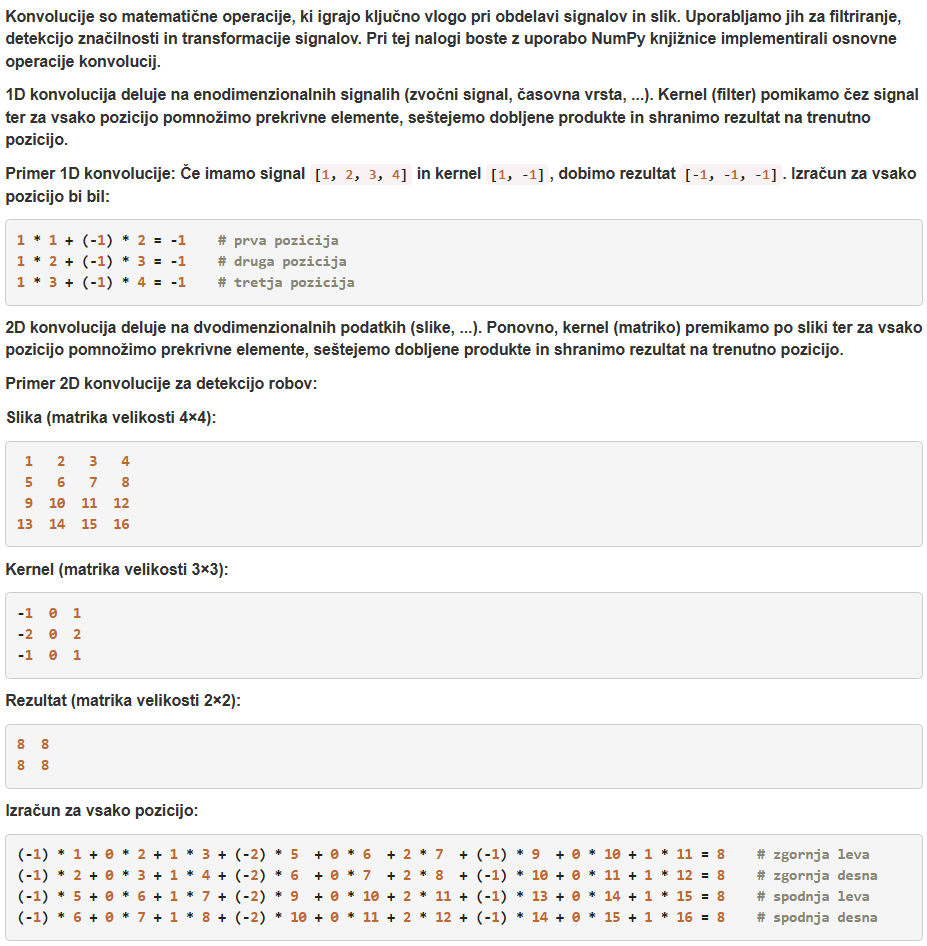

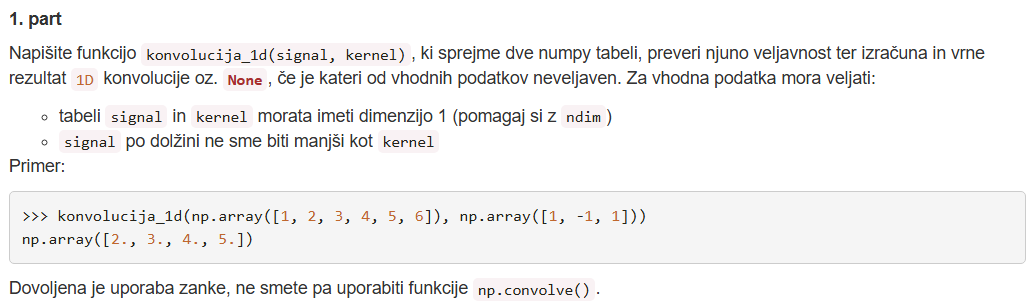

In [46]:
import numpy as np

def konvolucija_1d(signal, kernel):
    if signal.ndim != 1 or kernel.ndim != 1:
        return None
    if len(signal) < len(kernel):
        return None
    
    dolzina = len(signal) - len(kernel) + 1
    rezultat = np.zeros(dolzina)
    for i in range(dolzina):
        rezultat[i] = np.sum(signal[i:i + len(kernel)] * kernel)
    return rezultat

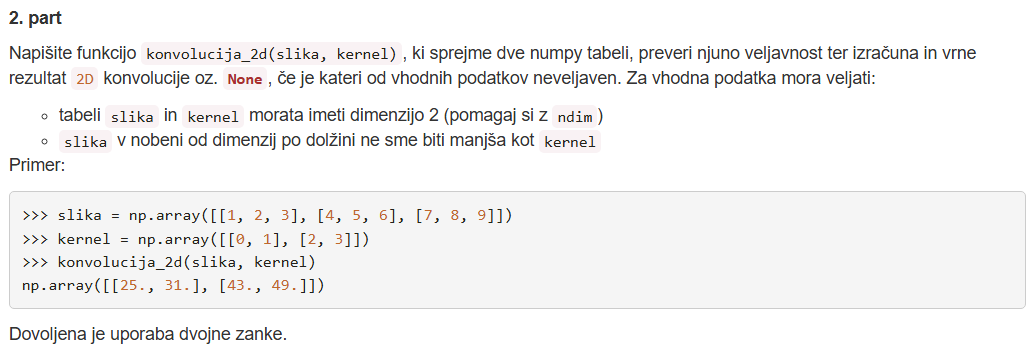

In [47]:
def konvolucija_2d(slika, kernel):
    if slika.ndim != 2 or kernel.ndim != 2:
        return None
    if slika.shape[0] < kernel.shape[0] or slika.shape[1] < kernel.shape[1]:
        return None
    
    s_visina, s_sirina = slika.shape
    k_visina, k_sirina = kernel.shape
    rezultat = np.zeros((s_visina - k_visina + 1, s_sirina - k_sirina + 1))
    for i in range(s_visina - k_visina + 1):
        for j in range(s_sirina - k_sirina + 1):
            rezultat[i, j] = np.sum(slika[i:i + k_visina, j:j + k_sirina] * kernel)
    return rezultat

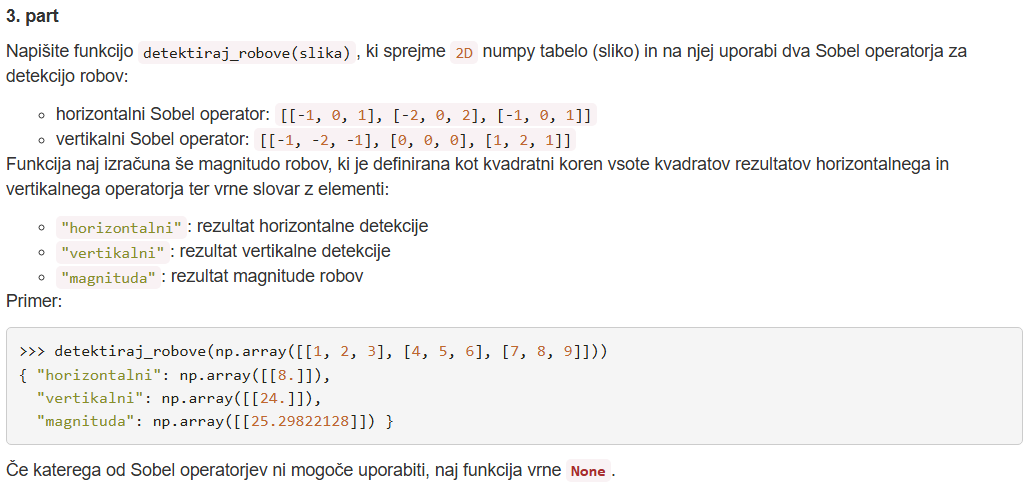

In [48]:
def detektiraj_robove(slika):
    sobel_h = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    grad_h = konvolucija_2d(slika, sobel_h)
    if grad_h is None:
        return None

    sobel_v = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    grad_v = konvolucija_2d(slika, sobel_v)
    if grad_v is None:
        return None

    magnituda = np.sqrt(grad_h ** 2 + grad_v ** 2)
    return {'horizontalni': grad_h, 'vertikalni': grad_v, 'magnituda': magnituda}

## 2. izpit 24/25

#### 1. naloga: Dvigala

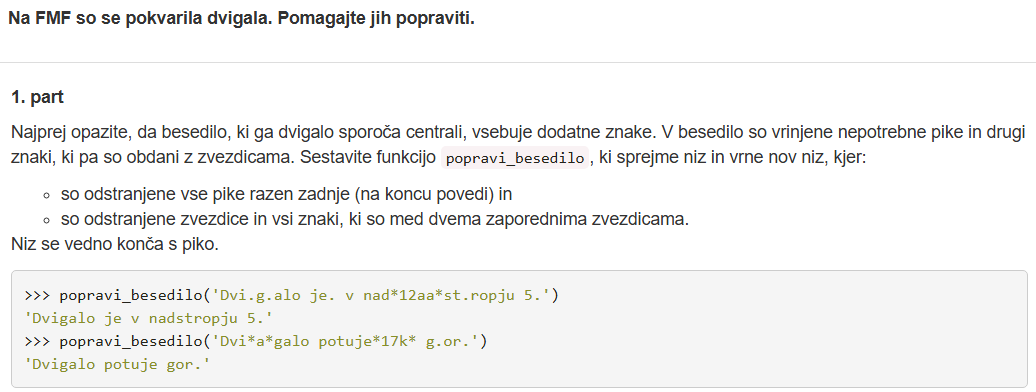

In [49]:
def popravi_besedilo(niz):
    nov_niz = ""
    zvezdica = False
    for znak in niz:
        if znak == '*':
            zvezdica = not zvezdica
        elif not zvezdica and znak != '.':
            nov_niz += znak
    return nov_niz + '.'

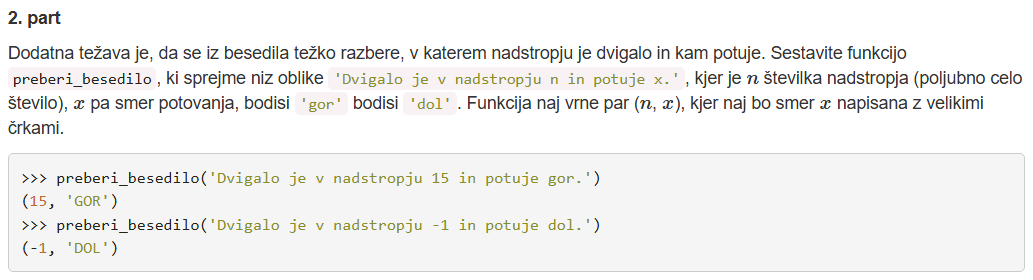

In [51]:
def preberi_besedilo(niz):
    d = len("Dvigalo je v nadstropju ")
    sez = niz[d:].split(" in potuje ")
    return int(sez[0]), sez[1][:-1].upper()

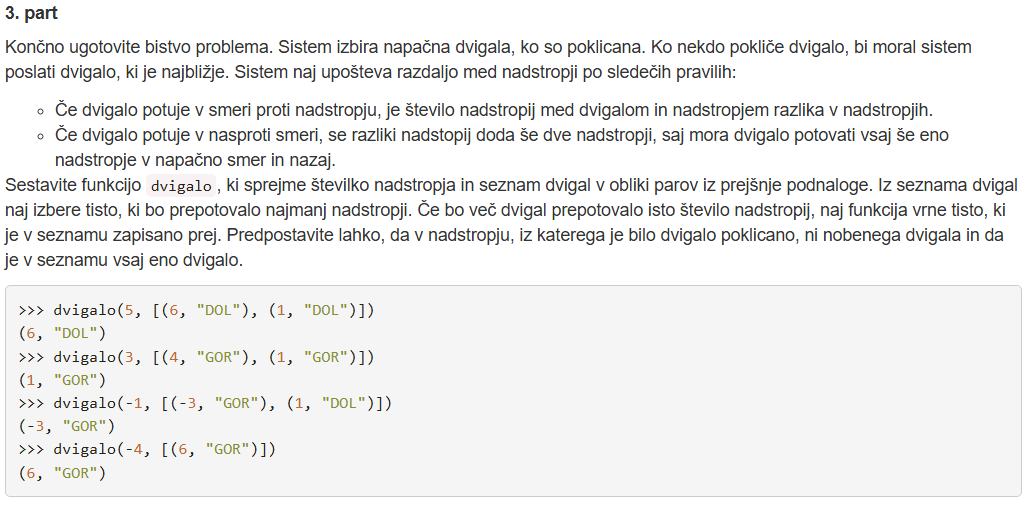

In [50]:
def razdalja(n, dvigalo):
    nadstropje, smer = dvigalo
    r = abs(n - nadstropje)
    if n > nadstropje and smer == 'DOL' or n < nadstropje and smer == 'GOR':
        r += 2
    return r

def dvigalo(n, sez):
    trenutno_dvigalo = sez[0]
    trenutna_razdalja = razdalja(n, trenutno_dvigalo)
    for dvigalo in sez:
        d = razdalja(n, dvigalo)
        if d < trenutna_razdalja:
            trenutno_dvigalo = dvigalo
            trenutna_razdalja = d
    return trenutno_dvigalo

#### 2. naloga: Osmerosmerke

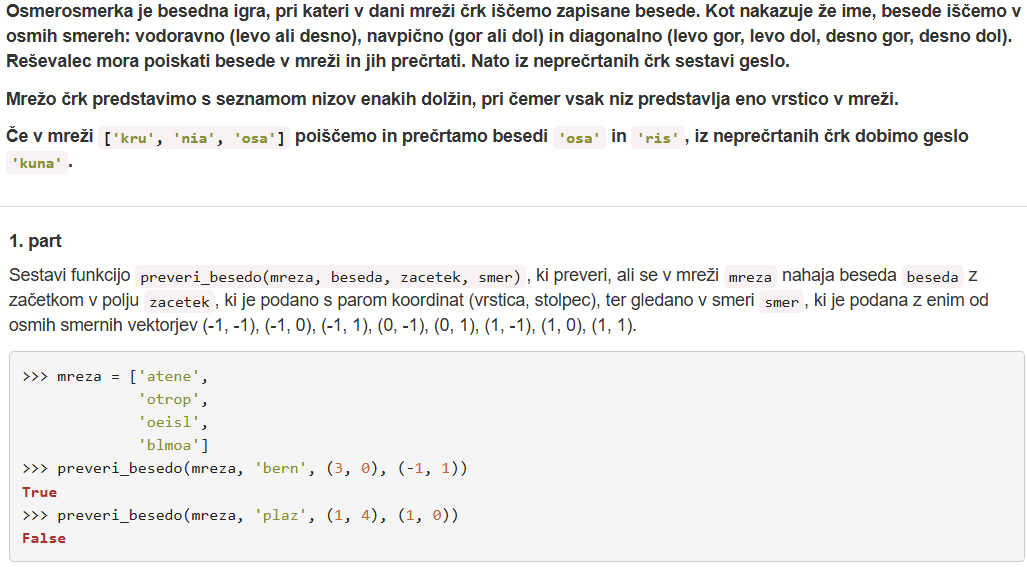

In [52]:
def preveri_besedo(mreza, beseda, zacetek, smer):
    visina = len(mreza)
    sirina = len(mreza[0])
    i, j = zacetek
    di, dj = smer
    for crka in beseda:
        if i < 0 or j < 0 or i >= visina or j >= sirina or crka != mreza[i][j]:
            return False
        i += di
        j += dj
    return True

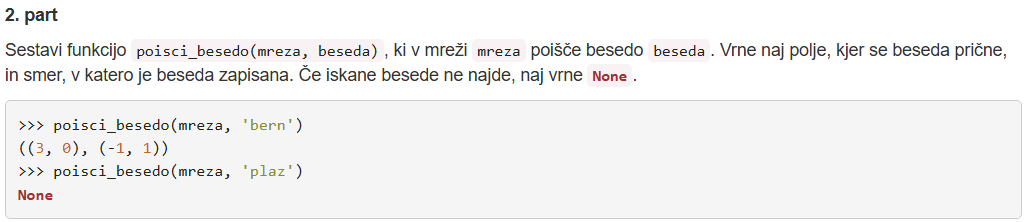

In [53]:
def poisci_besedo(mreza, beseda):
    for i in range(len(mreza)):
        for j in range(len(mreza[0])):
            for di in (-1, 0, 1):
                for dj in (-1, 0, 1):
                    if di == 0 and dj == 0:
                        continue
                    if preveri_besedo(mreza, beseda, (i, j), (di, dj)):
                        return (i, j), (di, dj)
    return None

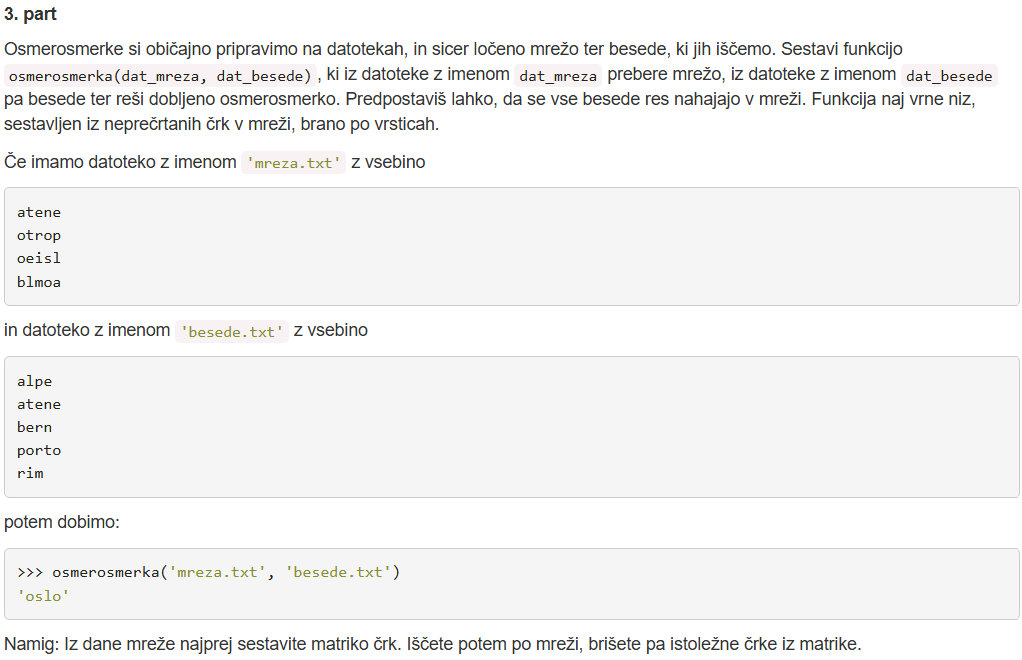

In [54]:
def osmerosmerka(dat_mreza, dat_besede):
    with open(dat_mreza, encoding='utf8') as f:
        mreza = f.read().strip('\n').split('\n')
    with open(dat_besede, encoding='utf8') as f:
        besede = f.read().strip('\n').split('\n')
    mat = [list(vrstica) for vrstica in mreza]
    for beseda in besede:
        (i, j), (di, dj) = poisci_besedo(mreza, beseda)
        for k in range(len(beseda)):
            mat[i + k * di][j + k * dj] = '.'
    niz = ''
    for vrstica in mat:
        for crka in vrstica:
            if crka != '.':
                niz += crka
    return niz

#### 3. naloga: Vremenska postaja

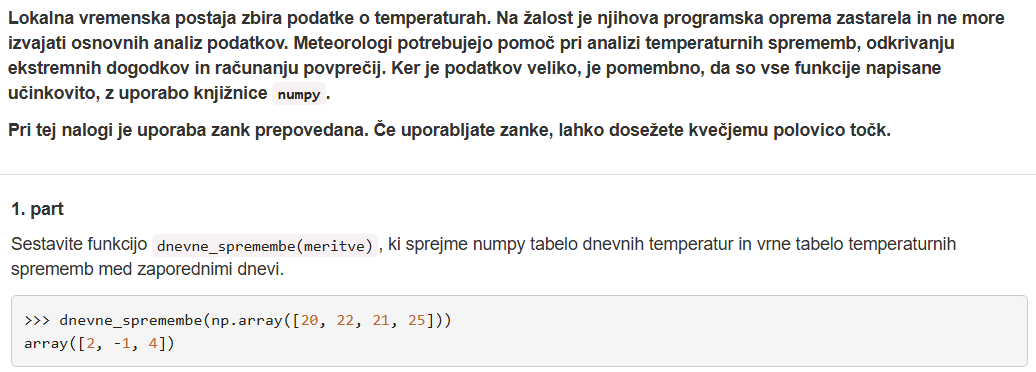

In [55]:
import numpy as np

def dnevne_spremembe(meritve):
    return meritve[1:] - meritve[:-1]

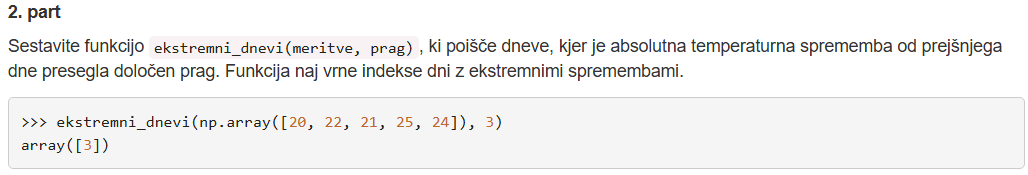

In [56]:
def ekstremni_dnevi(meritve, prag):
    spremembe = dnevne_spremembe(meritve)
    return np.where(np.abs(spremembe) > prag)[0] + 1

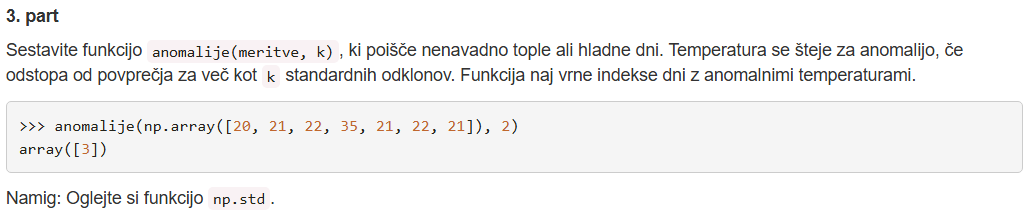

In [57]:
def anomalije(meritve, k):
    mean = np.mean(meritve)
    std = np.std(meritve)
    prag = std * k
    return np.flatnonzero(np.abs(meritve - mean) > prag)

## 3. izpit 24/25

#### 1. naloga: Analiza DNA

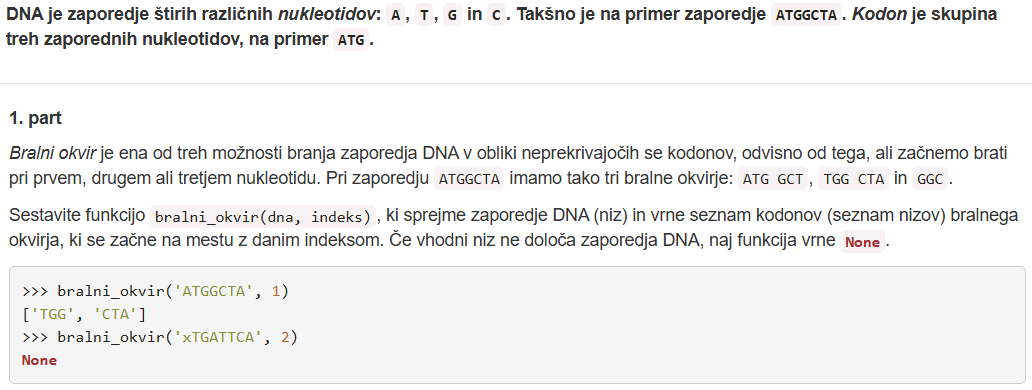

In [58]:
def bralni_okvir(dna, indeks):
    for nukleotid in dna:
        if nukleotid not in 'ATGC':
            return None
    okvir = []
    for i in range(indeks, len(dna) - 2, 3):
        okvir.append(dna[i:i + 3])
    return okvir

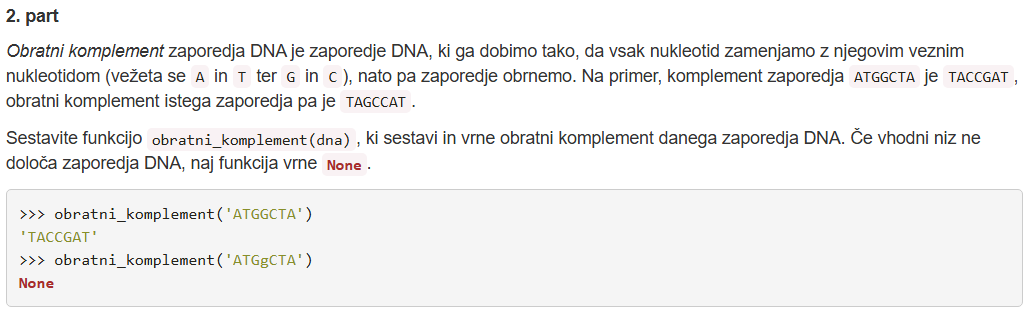

In [59]:
def obratni_komplement(dna):
    preslikava = {'A': 'T', 'T': 'A', 'G': 'C', 'C': 'G'}
    komplement = ''
    for nukleotid in dna:
        if nukleotid not in preslikava:
            return None
        komplement += preslikava[nukleotid]
    return komplement[::-1]

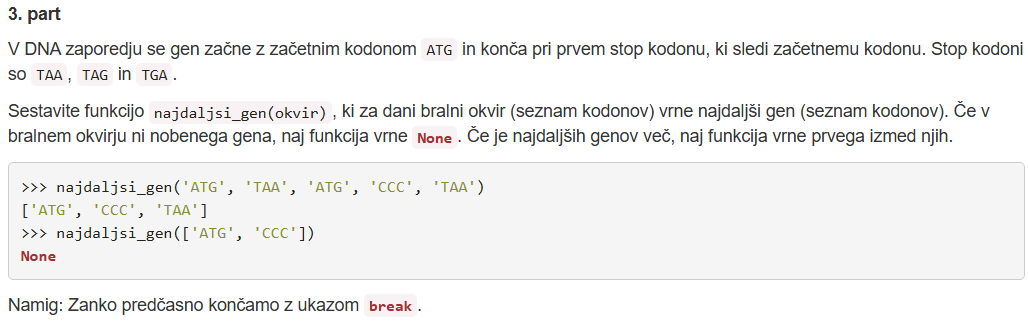

In [60]:
def najdaljsi_gen(okvir):
    zacetni_kodon = 'ATG'
    stop_kodoni = {'TAA', 'TAG', 'TGA'}
    gen = None
    gen_dolzina = 0
    for i in range(len(okvir)):
        if okvir[i] == zacetni_kodon:
            for j in range(i + 1, len(okvir)):
                if okvir[j] in stop_kodoni:
                    dolzina = j - i + 1
                    if dolzina > gen_dolzina:
                        gen = okvir[i:j + 1]
                        gen_dolzina = dolzina
                    break
    return gen

#### 2. naloga: Spitofy Wrapped

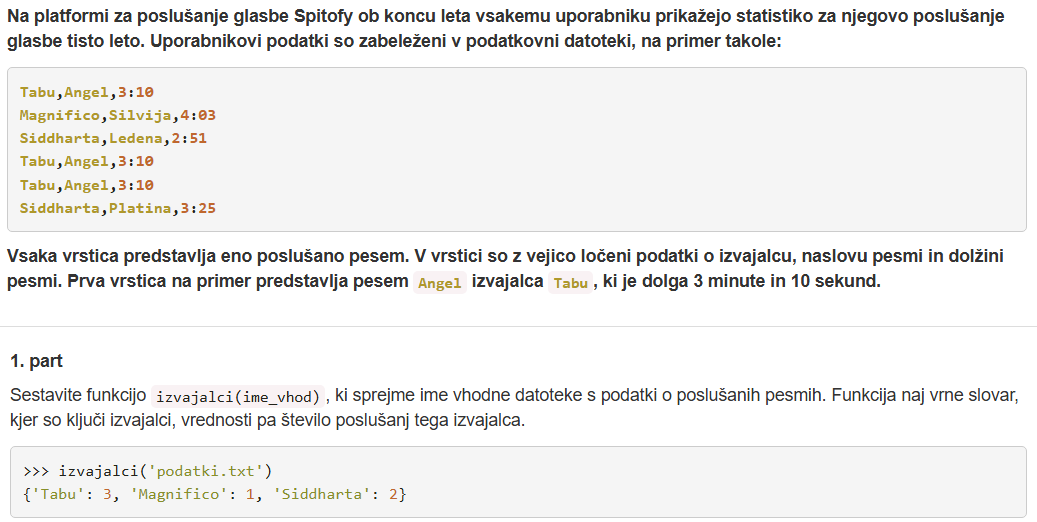

In [ ]:
def izvajalci(ime_vhod):
    slovar = {}
    with open(ime_vhod, encoding='utf8') as dat:
        for vrstica in dat:
            izvajalec, _, _ = vrstica.split(',')
            slovar.setdefault(izvajalec, 0)
            slovar[izvajalec] += 1
    return slova

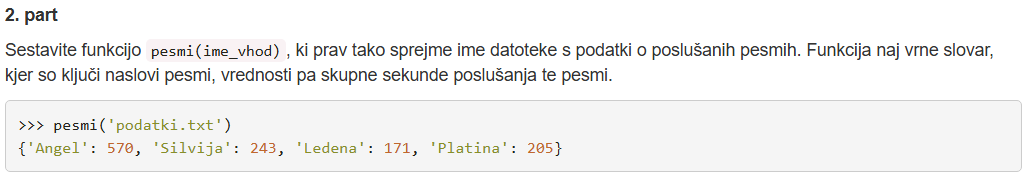

In [ ]:
def pesmi(ime_vhod):
    slovar = {}
    with open(ime_vhod, encoding='utf8') as dat:
        for vrstica in dat:
            _, pesem, dolzina = vrstica.split(',')
            minute, sekunde = dolzina.split(':')
            cas = 60 * int(minute) + int(sekunde)
            slovar.setdefault(pesem, 0)
            slovar[pesem] += cas
    return slovar

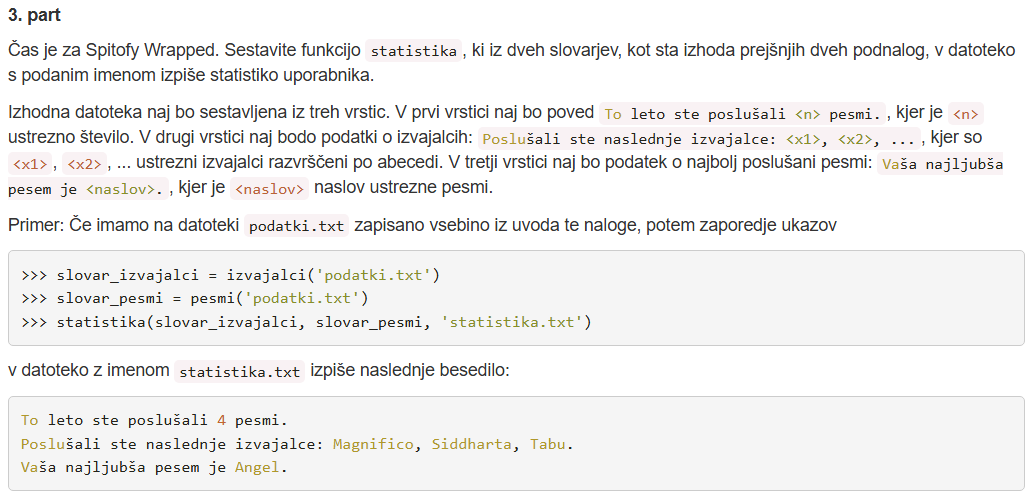

In [ ]:
ef statistika(slovar_izvajalci, slovar_pesmi, ime_izhod):
    with open(ime_izhod, 'w', encoding='utf8') as dat:
        dat.write(f"To leto ste poslušali {len(slovar_pesmi)} pesmi.\n")
        poslusani_izvajalci = list(slovar_izvajalci.keys())
        poslusani_izvajalci.sort()
        dat.write(f"Poslušali ste naslednje izvajalce: {', '.join(poslusani_izvajalci)}.\n")
        poslusane_pesmi = []
        for pesem, sekunde in slovar_pesmi.items():
            poslusane_pesmi.append((sekunde, pesem))
        poslusane_pesmi.sort(reverse=True)
        _, naj_pesem = poslusane_pesmi[0]
        dat.write(f"Vaša najljubša pesem je {naj_pesem}.")

#### 3. naloga: Geofizikalni observatorij Golovec

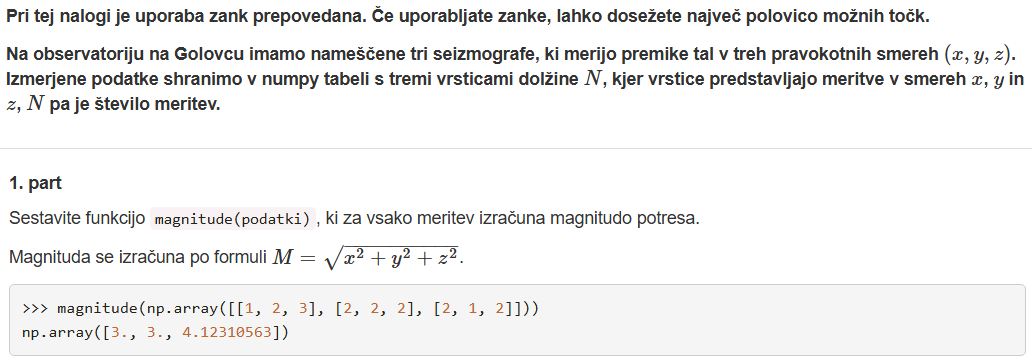

In [63]:
import numpy as np

def magnitude(podatki):
    kvadrati = podatki ** 2
    vsota_kvadratov = np.sum(kvadrati, axis=0)    
    return np.sqrt(vsota_kvadratov)

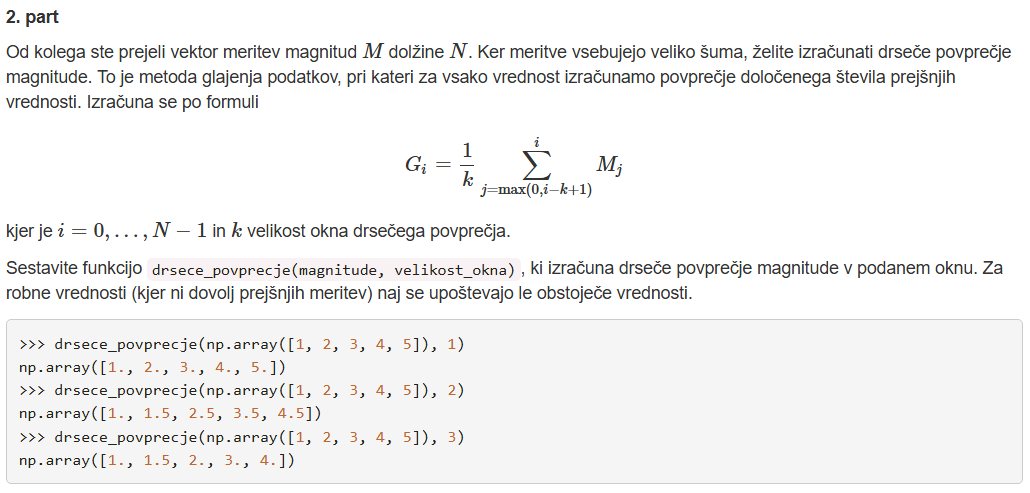

In [62]:
import numpy as np

def drsece_povprecje(magnitude, velikost_okna):
    kum_vsota = np.cumsum(magnitude)
    kum_vsota[velikost_okna:] -= kum_vsota[:-velikost_okna]
    dolzine_okna = np.minimum(np.arange(1, len(magnitude) + 1), velikost_okna)
    return kum_vsota / dolzine_okna

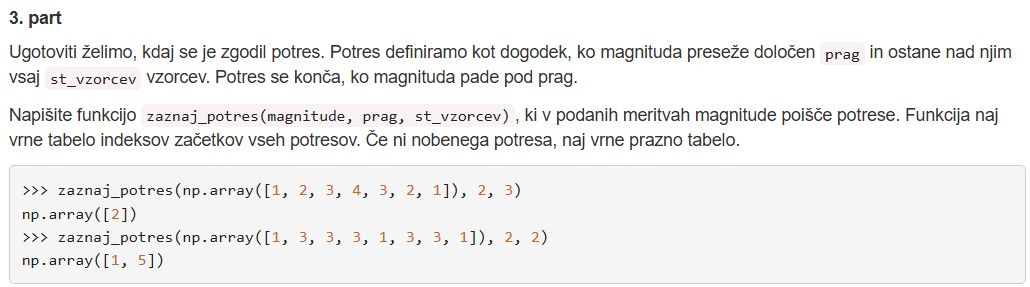

In [61]:
import numpy as np

def zaznaj_potres(magnitude, prag, st_vzorcev):
   nad_pragom = magnitude > prag
   razsirjen = np.concatenate(([False], nad_pragom, [False]))
   pogoj1 = razsirjen[1:] == True
   pogoj2 = razsirjen[:-1] == False
   zacetki = np.flatnonzero(np.where(pogoj1, pogoj2, False))
   pogoj1 = razsirjen[1:] == False
   pogoj2 = razsirjen[:-1] == True
   konci = np.flatnonzero(np.where(pogoj1, pogoj2, False))
   trajanja = konci - zacetki
   return zacetki[trajanja >= st_vzorcev]

## 1. izpit 25/26

#### 1. naloga: Kitaristka Ivana

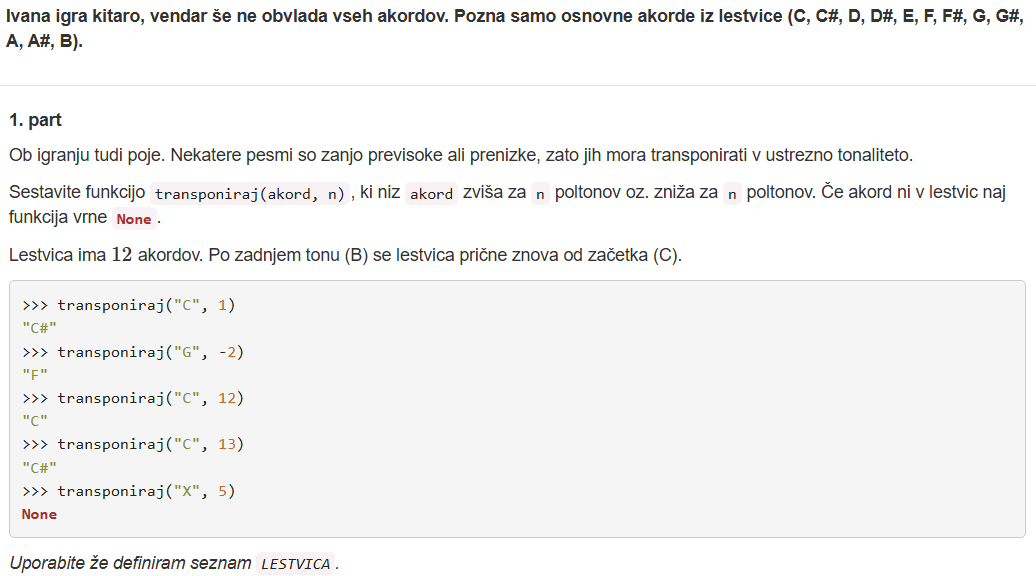

In [ ]:
LESTVICA = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

def transponiraj(akord, n):
    if akord in LESTVICA:
        indeks = LESTVICA.index(akord)
        nov_indeks = (indeks + n) % 12
        return LESTVICA[nov_indeks]
    else:
        return None

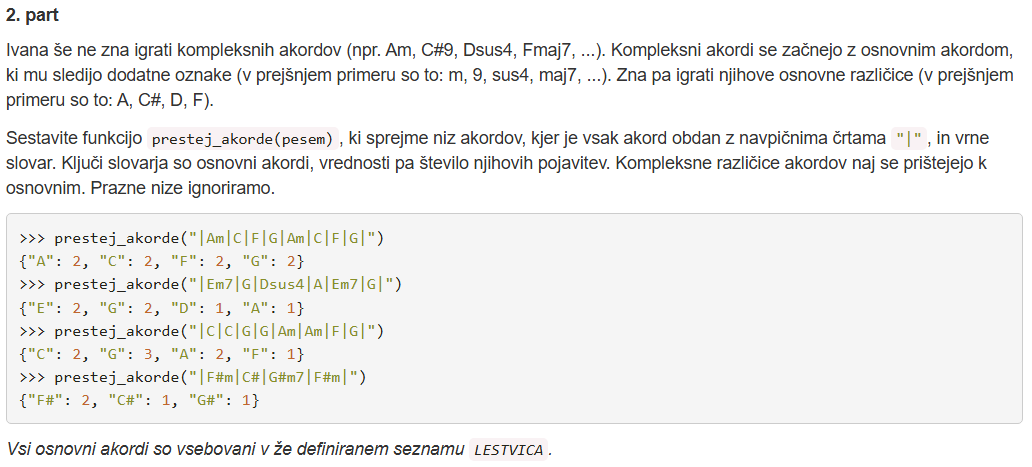

In [ ]:
LESTVICA = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

def prestej_akorde(pesem):
    stevec = dict()
    akordi = pesem.split("|")
    for akord in akordi:
        if akord == "":
            continue
        if akord[:2] in LESTVICA:
            poenostavljen = akord[:2]
        else:
            poenostavljen = akord[0]
        stevec[poenostavljen] = stevec.get(poenostavljen, 0) + 1
    return stevec

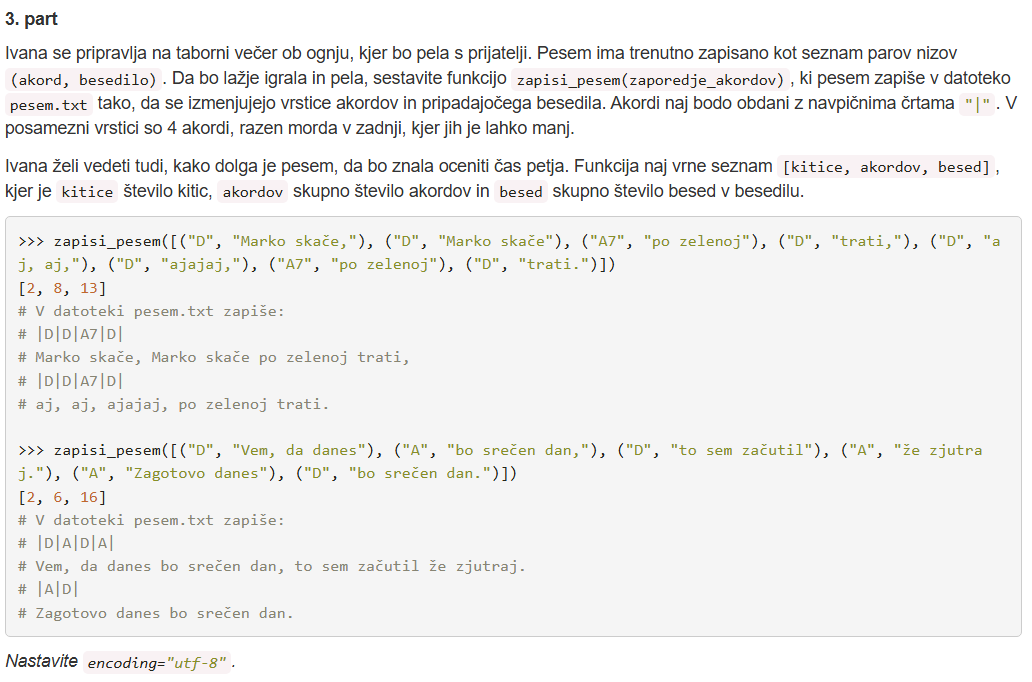

In [66]:
def zapisi_pesem(zaporedje_akordov):
    st_kitic = 0
    st_akordov = 0
    st_besed = 0
    with open("pesem.txt", "w", encoding="utf-8") as datoteka:
        akordi = []
        besedila = []
        for akord, besedilo in zaporedje_akordov:
            akordi.append(akord)
            besedila.append(besedilo)
            st_akordov += 1
            st_besed += len(besedilo.split())
            if len(akordi) == 4:
                datoteka.write("|" + "|".join(akordi) + "|\n")
                datoteka.write(" ".join(besedila) + "\n")
                st_kitic += 1
                akordi = []
                besedila = []
        if len(akordi) > 0:
            datoteka.write("|" + "|".join(akordi) + "|\n")
            datoteka.write(" ".join(besedila) + "\n")
            st_kitic += 1
    return [st_kitic, st_akordov, st_besed]

#### 2. naloga: Plavalni tečaj

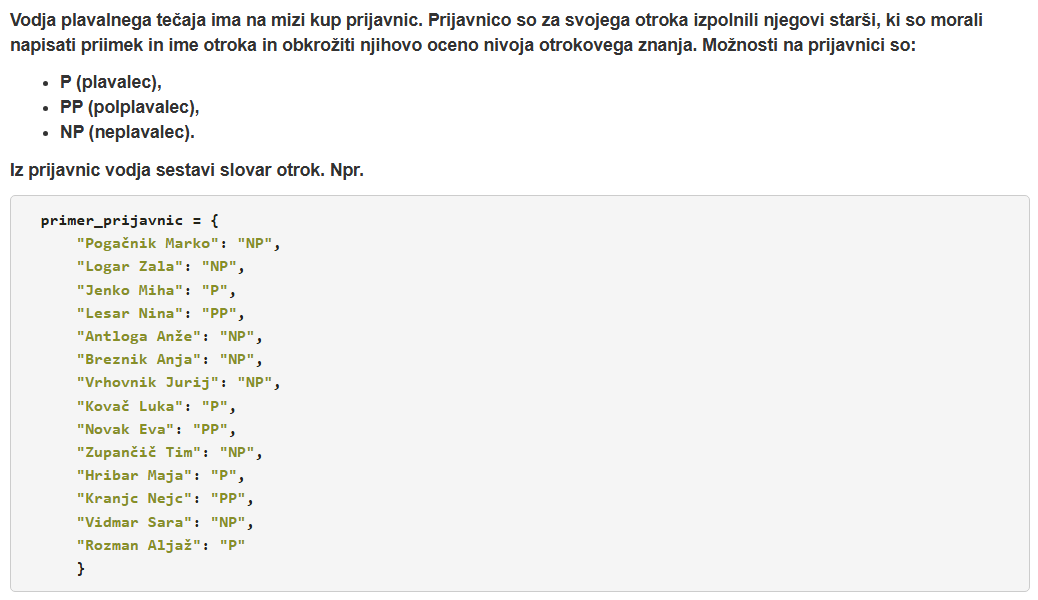

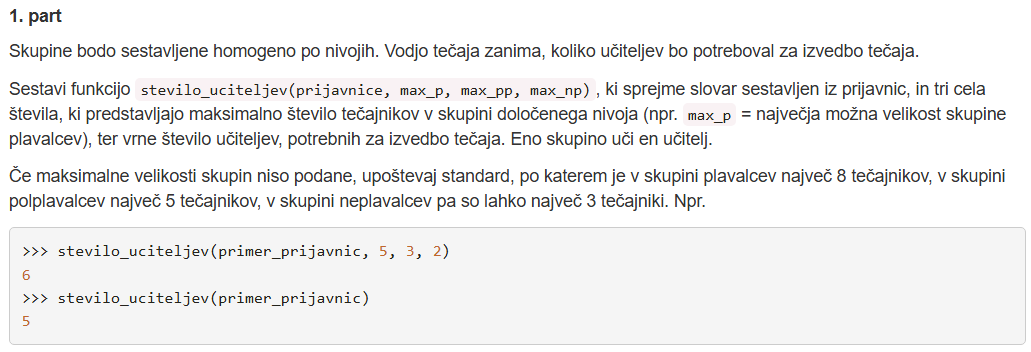

In [ ]:
import math

def stevilo_uciteljev(prijavnice, max_p=8, max_pp=5, max_np=3):
    znanja = list(prijavnice.values())
    stopnje = ["P", "PP", "NP"]
    meje = [max_p, max_pp, max_np]
    ucitelji = 0
    for i in range(3):
        ucitelji += math.ceil(znanja.count(stopnje[i]) / meje[i])
    return ucitelji

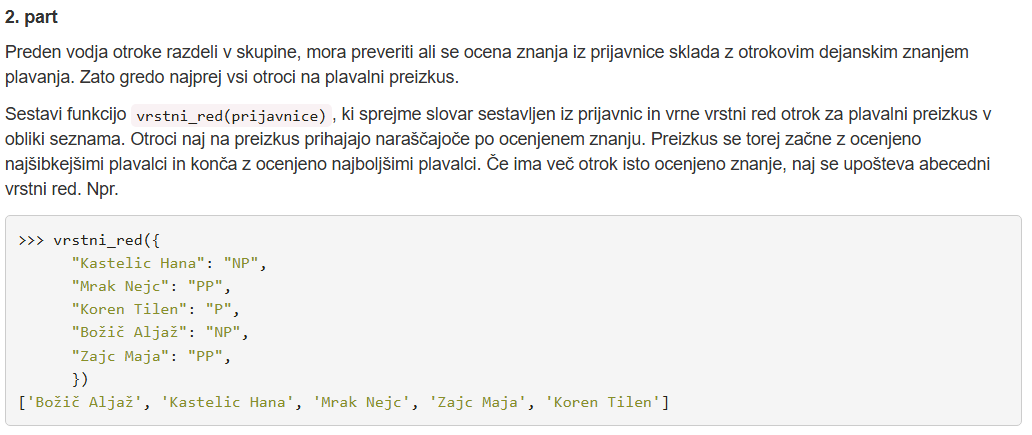

In [ ]:
def vrstni_red(prijavnice):
    stevilcna_ocena = {"NP" : 0, "PP": 1, "P" : 2}
    s = {}
    for otrok, znanje in prijavnice.items():
          s[otrok] = stevilcna_ocena[znanje]
    urejen = dict(sorted(s.items(), key=lambda x: (x[1], x[0])))
    return list(urejen.keys())

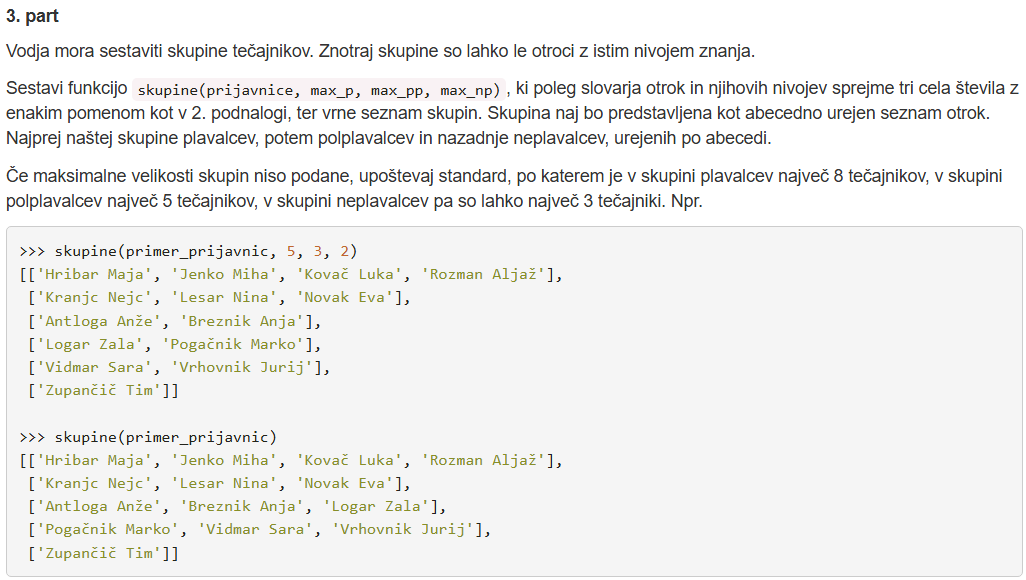

In [ ]:
def inverz(prijavnice):
    stopnje = ["P", "PP", "NP"]
    s = {}
    for st in stopnje: s[st] = []
    for otrok, znanje in prijavnice.items(): s[znanje] += [otrok]
    for st in stopnje: s[st] = sorted(s[st])
    return s

def skupine(prijavnice, max_p=8, max_pp=5, max_np=3):
    po_znanju = inverz(prijavnice)
    stopnje = ["P", "PP", "NP"]
    maxi = [max_p, max_pp, max_np]
    skupine = []
    for i in range(3):
        st = stopnje[i]
        max = maxi[i]
        o = po_znanju[st]
        while len(o) >= 3:
            skupine.append(o[:max])
            o = o[max:]
        if len(o) > 0:
            skupine.append(o)
    return skupine

#### 3. naloga: Polarni premiki v ravnini

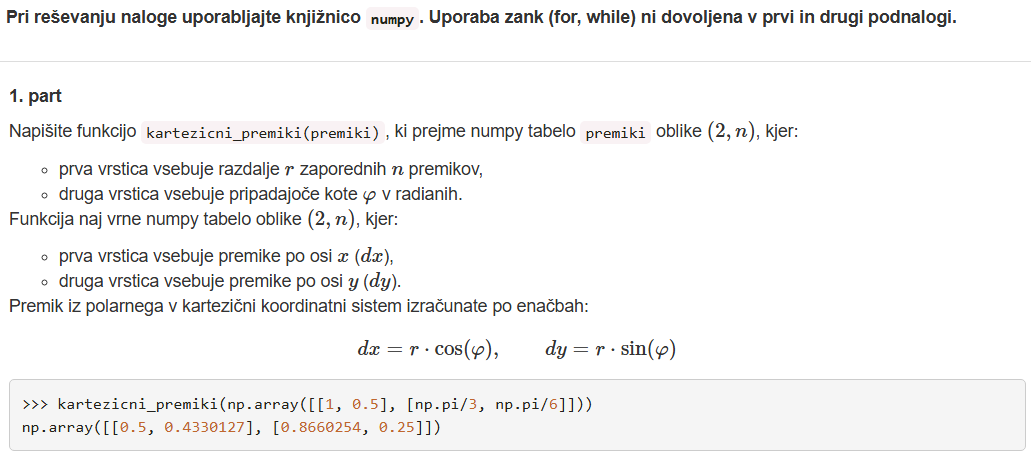

In [ ]:
import numpy as np

def kartezicni_premiki(premiki):
    dx = premiki[0] * np.cos(premiki[1])
    dy = premiki[0] * np.sin(premiki[1])
    return np.array([dx, dy])

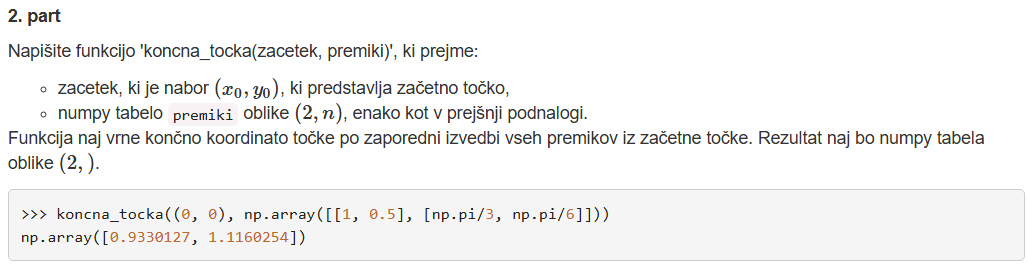

In [ ]:
import numpy as np

def koncna_tocka(zacetek, premiki):
    kartezicni = kartezicni_premiki(premiki) # pridobimo kartezične premike
    x = np.sum(kartezicni[0]) + zacetek[0] # končna x koordinata
    y = np.sum(kartezicni[1]) + zacetek[1] # končna y koordinata
    return np.array([x, y])

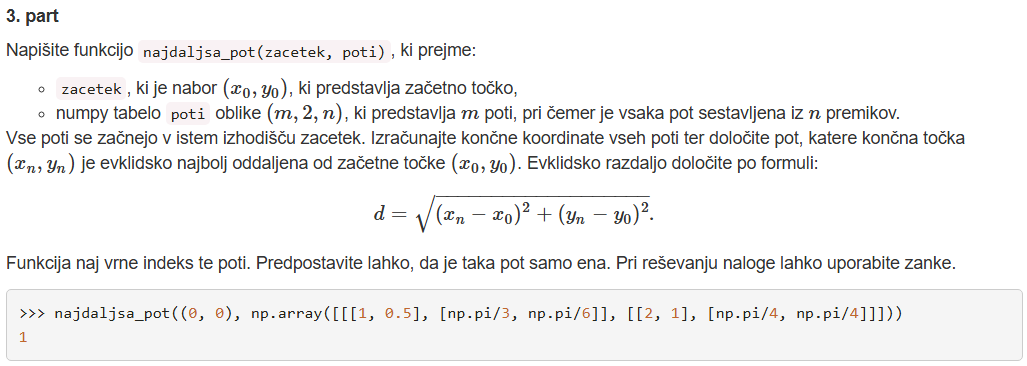

In [ ]:
import numpy as np

def najdaljsa_pot(zacetek, poti):
    m = poti.shape[0] # število poti
    razdalje = np.zeros(m)
    for i in range(m):  # za vsako pot
        koncna_lega = koncna_tocka(zacetek, poti[i])  # končna točka i-te poti
        razdalje[i] = np.linalg.norm(koncna_lega - np.array(zacetek)) # evklidska razdalja do začetne točke
    return int(np.argmax(razdalje)) # indeks najdaljše poti

## 2. izpit 25/26

#### 1. naloga: Ocenjevanje

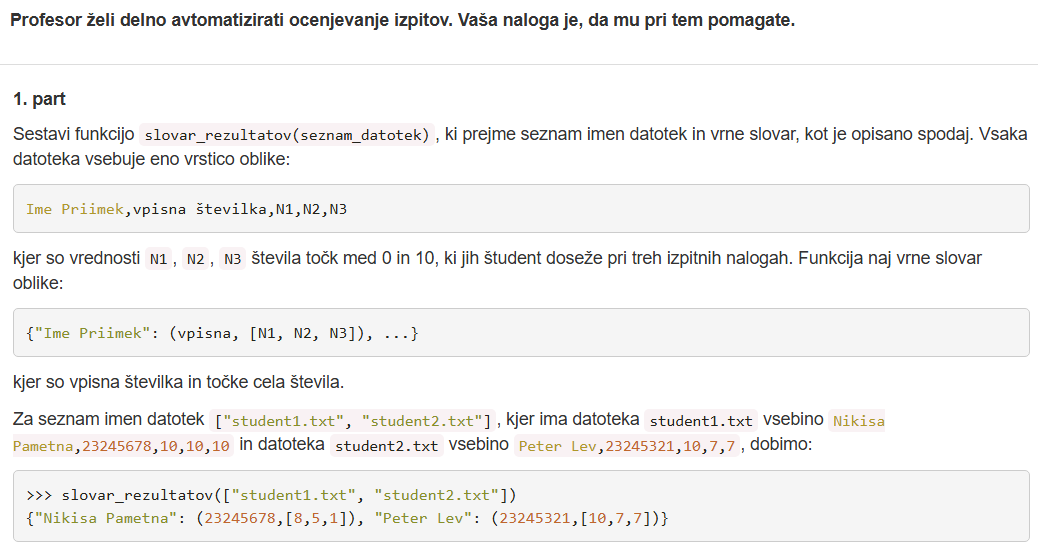

In [ ]:
def slovar_rezultatov(seznam_datotek):
    slovar = {}
    for datoteka in seznam_datotek:
        with open(datoteka, 'r') as f:
            vsebina = f.read()
            seznam_vsebine = vsebina.split(",")
            slovar[seznam_vsebine[0]] = (int(seznam_vsebine[1]), [int(x) for x in seznam_vsebine[2:]])
    return slovar

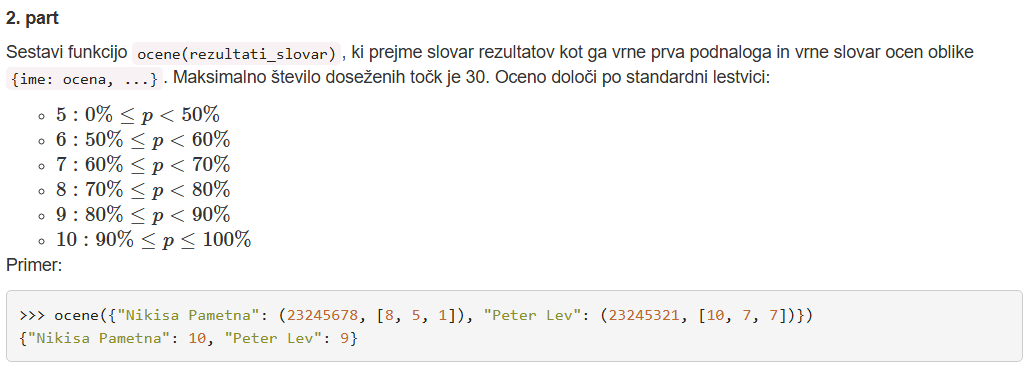

In [ ]:
def ocene(slovar_rezultatov):
    slovar = {}
    for oseba, (vpisna, seznam) in slovar_rezultatov.items():
        p = sum(seznam) / 30 # izračunamo dosežen procent
        # po alinejah iz navodil naloge določimo oceno
        if p < 0.5:
            ocena = 5
        elif p < 0.6:
            ocena = 6
        elif p < 0.7:
            ocena = 7
        elif p < 0.8:
            ocena = 8
        elif p < 0.9:
            ocena = 9
        else:
            ocena = 10 
        slovar[oseba] = ocena
    return slovar

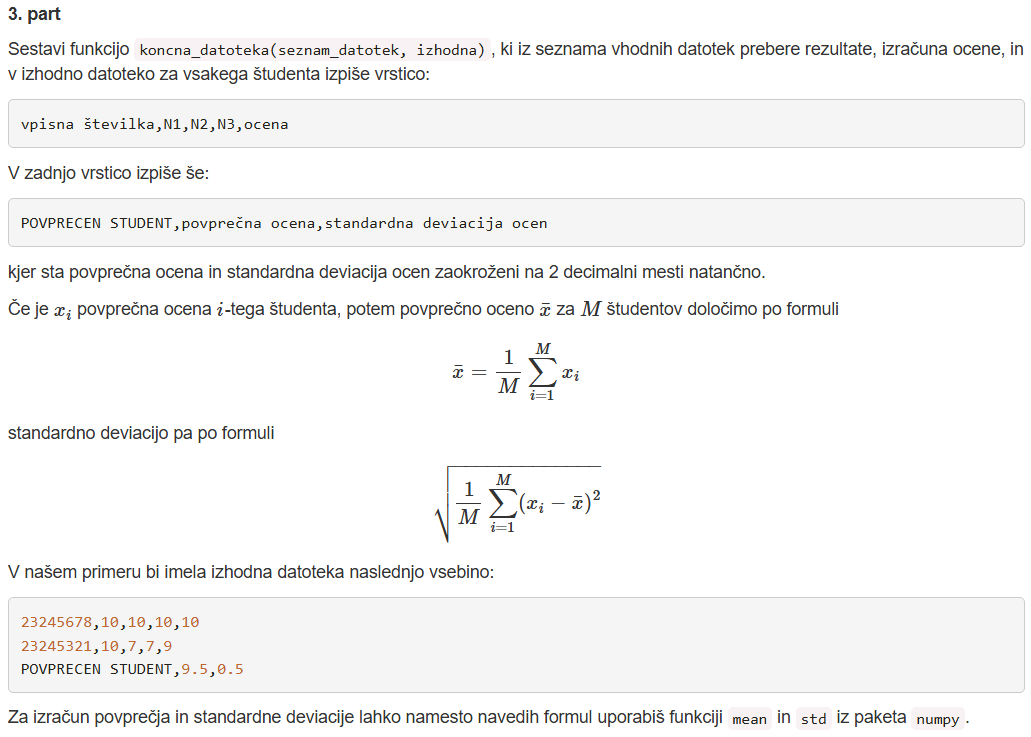

In [ ]:
import numpy as np 

def koncna_datoteka(seznam_datotek, izhodna):
    rezultati_slovar = slovar_rezultatov(seznam_datotek)
    ocene_slovar = ocene(rezultati_slovar)

    arrey_ocen = np.array(list(ocene_slovar.values()))
    povprecje = np.mean(arrey_ocen)
    varianca = np.std(arrey_ocen)
    with open(izhodna, "w") as f:
        for oseba, (vpisna, seznam) in rezultati_slovar.items():
            ocena = ocene_slovar[oseba]
            vrednosti = [vpisna, *seznam, ocena]
            print(",".join(str(int(x)) for x in vrednosti), file=f)
        print(f"POVPRECEN STUDENT,{round(povprecje,2)},{round(varianca,2)}", file=f)

#### 2. naloga: Parkirišče

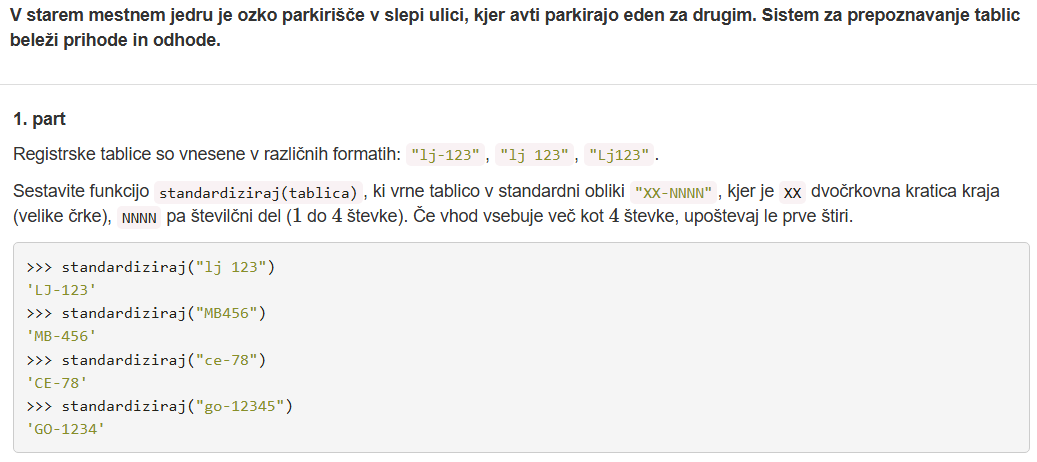

In [ ]:
def standardiziraj(tablica):
    tablica = tablica.replace(" ", "").replace("-", "").upper()
    return tablica[:2] + "-" + tablica[2:6]

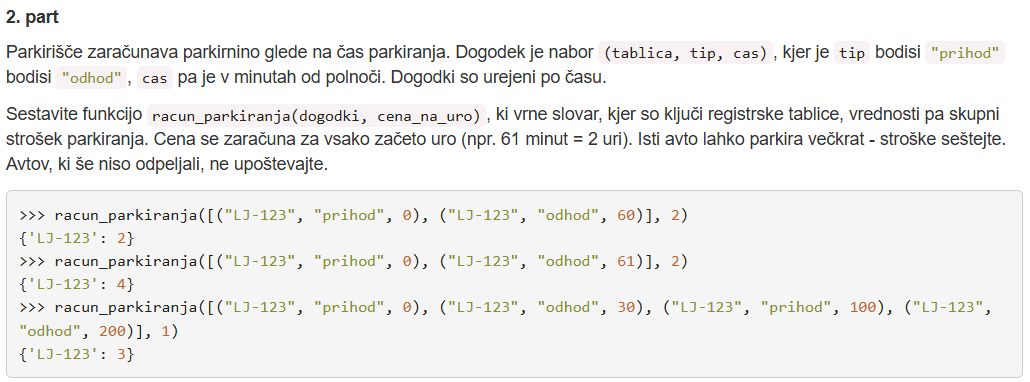

In [ ]:
def racun_parkiranja(dogodki, cena_na_uro):
    prihodi = {}
    strosek = {}
    
    for dogodek in dogodki:
        tablica, tip, cas = dogodek
        
        if tip == "prihod":
            prihodi[tablica] = cas
        elif tip == "odhod":
            minute = cas - prihodi[tablica]
            ure = (minute + 59) // 60
            strosek[tablica] = strosek.get(tablica, 0) + ure * cena_na_uro
    
    return strosek

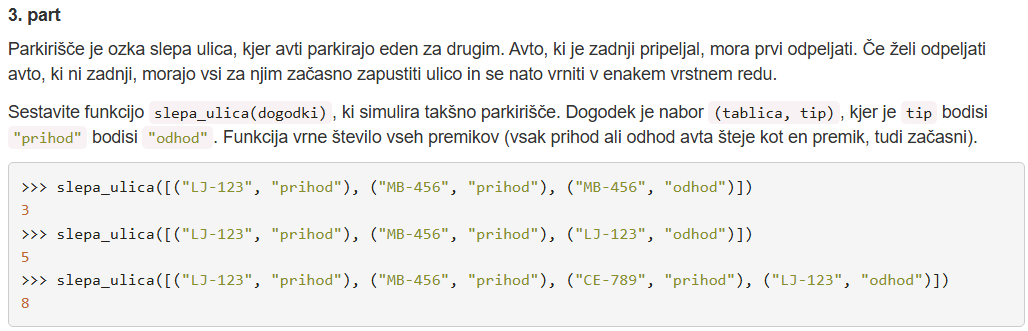

In [ ]:
def slepa_ulica(dogodki):
    ulica = []
    premiki = 0
    
    for tablica, dogodek in dogodki:
        if dogodek == "prihod":
            ulica.append(tablica)
            premiki += 1
        elif dogodek == "odhod":
            zacasno = []
            while ulica[-1] != tablica:
                zacasno.append(ulica.pop())
                premiki += 1
            
            ulica.pop()
            premiki += 1
            
            while zacasno:
                ulica.append(zacasno.pop())
                premiki += 1
    
    return premiki

#### 3. naloga: Jadranla regata

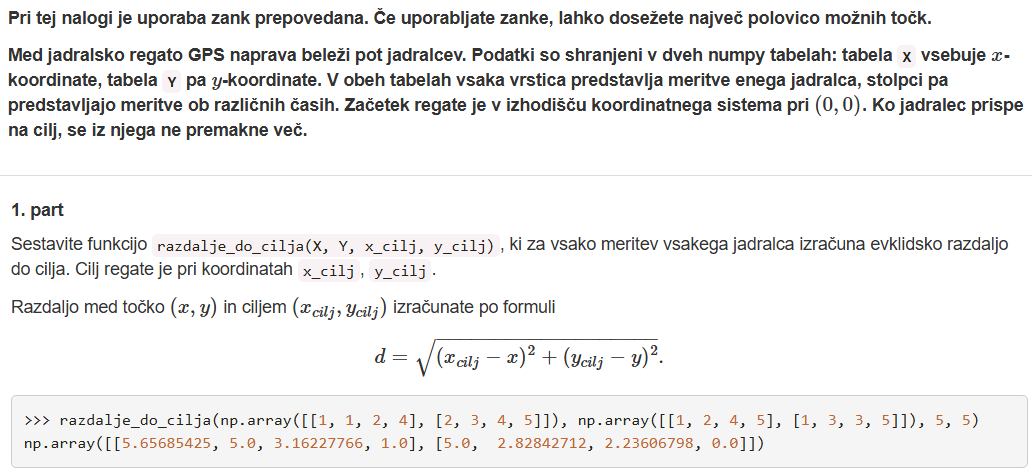

In [ ]:
import numpy as np

def razdalje_do_cilja(X, Y, x_cilj, y_cilj):
    dx = x_cilj - X
    dy = y_cilj - Y
    return np.sqrt(dx**2 + dy**2)

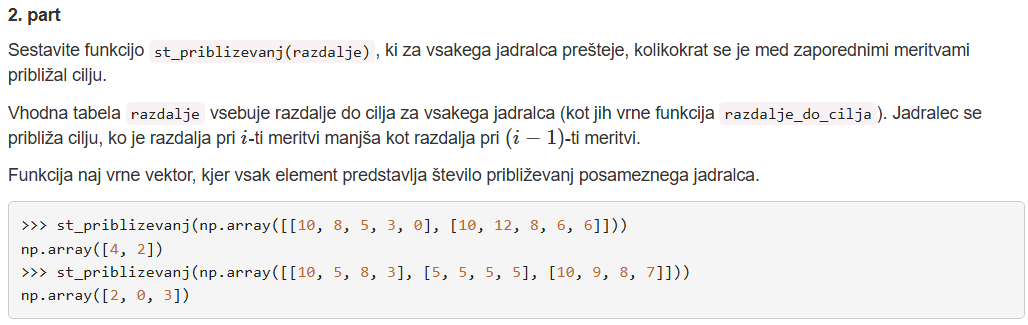

In [ ]:
import numpy as np

def st_priblizevanj(razdalje):
    razdalje_prej = np.roll(razdalje, 1, axis=1)
    priblizevanje = razdalje_prej > razdalje
    priblizevanje[:, 0] = False
    return np.sum(priblizevanje, axis=1)

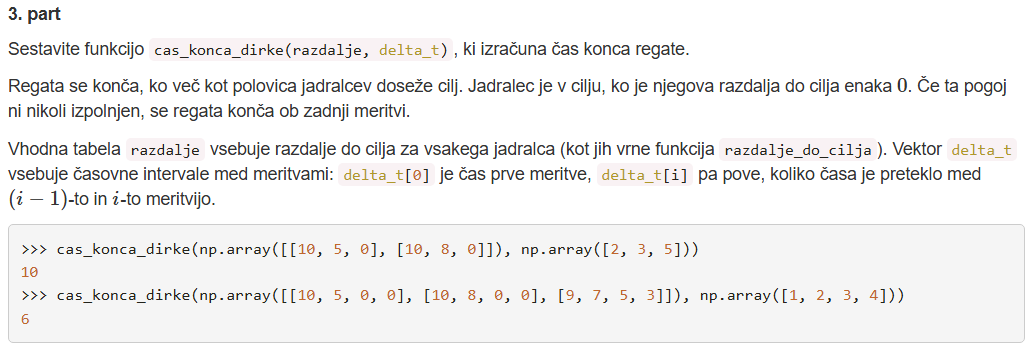

In [ ]:
import numpy as np

def cas_konca_dirke(razdalje, delta_t):
    v_cilju = razdalje == 0
    st_jadralcev_v_cilju = np.sum(v_cilju, axis=0)
    st_jadralcev = razdalje.shape[0]
    indeksi = np.where(st_jadralcev_v_cilju > (st_jadralcev / 2))
    t = np.cumsum(delta_t)
    
    if len(indeksi[0]) > 0:
        return t[indeksi[0][0]]
    else:
        return t[-1]